# P.6. Callable Agency Bond OAS Strategy

## Submitted by: Group B8 - Rajdeep Choudhary, Vidhi Jain, Aaron Jay, Lucie Martin
---

## Project Statement

Analyze a panel of callable agency bonds (Freddie Mac, Fannie Mae, FHLB), construct a mean-reversion trading strategy based on OAS z-scores, and decompose the strategy’s P&L into spread compression, option repricing, and carry components across the 2022–2025 rate cycle.



## Context

### Agency Callable Bonds and the Ch 6 Framework

Agency callable bonds are the canonical application of the OAS framework from Ch 6. The bondholder is short an embedded call option: the issuer (Freddie Mac, Fannie Mae, or FHLB) can redeem the bond at par after the first call date. This creates the decomposition:

$$\text{Z-spread} = \text{OAS} + \text{Option Cost}$$

The **Z-spread** is the flat spread over the swap curve needed to match the bond's market price, ignoring the call option. The **OAS** (option-adjusted spread) accounts for the issuer's call right using a rate model. The difference is the **option cost**—the compensation the bondholder demands for being short the call.

### Why OAS for Trading Signals

Raw spread measures (Z-spread, yield spread) conflate two effects: (1) whether the bond is cheap or expensive relative to its credit, and (2) whether the embedded option is expensive or cheap. When implied volatility rises, the option cost increases, widening the Z-spread even if the bond's credit hasn't changed. A naive Z-spread signal would misidentify this as a buying opportunity.

OAS strips out the option effect. If OAS is wide relative to recent history (after accounting for the call), the bond is genuinely cheap. A mean-reversion strategy buys wide-OAS bonds and sells tight-OAS bonds, betting on spread normalization.

### The 2022–2025 Rate Cycle

The sample period spans a dramatic rate environment:

| Period              | Regime            | Fed Funds      | Effect on Callables                              |
|---------------------|-------------------|----------------|--------------------------------------------------|
| Jan 2022 – Sep 2022 | Hiking starts     | 0.25% → ~3.25% | High-coupon calls go from ITM to ATM             |
| Oct 2022 – Jun 2023 | Aggressive hiking | ~3.25% → 5.25% | Calls move OTM, option cost changes dramatically |
| Jul 2023 – Aug 2024 | Pause at peak     | 5.25–5.50%     | Stable option cost, carry matters                |
| Sep 2024 – Dec 2025 | Easing begins     | 5.50% → 4.50%+ | Calls drift back toward ATM                      |

This creates rich variation in call moneyness, option cost, and OAS behavior—exactly the variation needed to study when and why an OAS-based strategy works.

## Data Preview


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Go one level up from vidhi's/ folder to reach FI_Deriv_FinalProject_B8/
DATA_PATH = Path('../_DATA')

In [2]:
# Load callable agency panel (use most recent file)
panel_file = sorted(DATA_PATH.glob('callable_agency_panel_*.xlsx'))[-1]
print(f'Panel file: {panel_file.name}')

info = pd.read_excel(panel_file, sheet_name='info', index_col=0)
quotes = pd.read_excel(panel_file, sheet_name='quotes', index_col=0)
oas = pd.read_excel(panel_file, sheet_name='oas', index_col=0, parse_dates=True)
zsprd = pd.read_excel(panel_file, sheet_name='z_spread', index_col=0, parse_dates=True)
opt_cost = pd.read_excel(panel_file, sheet_name='option_cost', index_col=0, parse_dates=True)
clean = pd.read_excel(panel_file, sheet_name='clean_prices', index_col=0, parse_dates=True)
dirty = pd.read_excel(panel_file, sheet_name='dirty_prices', index_col=0, parse_dates=True)

oas.index = pd.to_datetime(oas.index)
zsprd.index = pd.to_datetime(zsprd.index)
opt_cost.index = pd.to_datetime(opt_cost.index)
clean.index = pd.to_datetime(clean.index)
dirty.index = pd.to_datetime(dirty.index)

print(f'Static bonds: {len(info.columns)}')
print(f'OAS time series: {oas.shape[1]} bonds, {oas.shape[0]} dates')
print(f'Prices/Z-spread: {clean.shape[1]} bonds')
print(f'Date range: {oas.index[0].date()} to {oas.index[-1].date()}')

Panel file: callable_agency_panel_2026-03-03.xlsx
Static bonds: 26
OAS time series: 25 bonds, 1043 dates
Prices/Z-spread: 15 bonds
Date range: 2022-01-03 to 2025-12-31


In [3]:
# Load supporting data
swaps = pd.read_excel(DATA_PATH / 'sofr_swaps.xlsx', sheet_name='data',
                       index_col=0, parse_dates=True)
swaps.index = pd.to_datetime(swaps.index)

gsw = pd.read_excel(DATA_PATH / 'gsw_yields.xlsx', index_col=0, parse_dates=True)
gsw.index = pd.to_datetime(gsw.index)

rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data',
                       index_col=0, parse_dates=True)
rates.index = pd.to_datetime(rates.index)

In [4]:
# Snapshot: bond properties and analytics
print('Bond Properties:')
display(info)

print('\nSnapshot Analytics:')
display(quotes)

Bond Properties:


,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 4.75 06/15/28,FHLB 5 01/15/30,FHLB 5 09/28/32,FHLB 5 12/15/27,FHLB 5.25 03/28/29,FHLB 5.5 12/28/28,...,FHLMC 5.5 09/28/28,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FNMA 5 03/15/30,FHLB 4.875 01/28/36,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
info,,,,,,,,,,,,,,,,,,,,,
CUSIP,3130AKTB2,3130ANWL0,3130B5Q50,3130AYLD6,3130B6TU0,3130B4KU4,3130ATBY2,3130B43K5,3130B0M55,NaN,...,NaN,3136G44J9,3136G44Q3,3136GADR7,3130B96U9,3130B1GC5,3130B1HQ3,3130B65Z5,3130B4B59,3130B1EY9
Issuer,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,...,FREDDIE MAC,FANNIE MAE,FANNIE MAE,FANNIE MAE,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK
Maturity Type,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,NaN,...,NaN,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE
Amount Issued,30000000,50000000,30000000,60000000,50000000,100000000,50000000,230000000,40000000,NaN,...,NaN,50000000,25000000,15000000,55000000,25000000,30000000,105000000,20000000,15000000
Cpn Rate,0.02,0.02,0.0425,0.0425,0.0475,0.05,0.05,0.05,0.0525,0.055,...,0.055,0.01,0.015,0.05,0.04875,0.04875,0.05125,0.0525,0.05375,0.055
Cpn Freq,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Date Issued,2021-01-28 00:00:00,2021-09-15 00:00:00,2025-03-28 00:00:00,2024-01-19 00:00:00,2025-06-30 00:00:00,2025-01-15 00:00:00,2022-09-28 00:00:00,2024-12-27 00:00:00,2024-03-28 00:00:00,NaN,...,NaN,2020-09-28 00:00:00,2020-09-28 00:00:00,2025-03-28 00:00:00,2026-01-28 00:00:00,2024-05-20 00:00:00,2024-05-29 00:00:00,2025-05-15 00:00:00,2024-12-18 00:00:00,2024-05-15 00:00:00
Date Matures,2031-01-28 00:00:00,2031-09-15 00:00:00,2030-03-28 00:00:00,2028-12-28 00:00:00,2028-06-15 00:00:00,2030-01-15 00:00:00,2032-09-28 00:00:00,2027-12-15 00:00:00,2029-03-28 00:00:00,2028-12-28 00:00:00,...,2028-09-28 00:00:00,2029-09-28 00:00:00,2035-09-28 00:00:00,2030-03-15 00:00:00,2036-01-28 00:00:00,2028-09-28 00:00:00,2029-05-15 00:00:00,2035-05-15 00:00:00,2034-12-15 00:00:00,2034-05-15 00:00:00
Date First Call,2021-04-28 00:00:00,2021-12-15 00:00:00,2028-03-28 00:00:00,2027-06-28 00:00:00,2025-09-15 00:00:00,2026-01-15 00:00:00,2023-09-28 00:00:00,2025-01-15 00:00:00,2025-03-28 00:00:00,NaN,...,NaN,2022-09-28 00:00:00,2022-09-28 00:00:00,2025-09-15 00:00:00,2026-07-28 00:00:00,2026-09-28 00:00:00,2026-05-15 00:00:00,2026-05-15 00:00:00,2027-06-15 00:00:00,2026-05-15 00:00:00



Snapshot Analytics:


,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 4.75 06/15/28,FHLB 5 01/15/30,FHLB 5 09/28/32,FHLB 5 12/15/27,FHLB 5.25 03/28/29,FHLB 5.5 12/28/28,...,FHLMC 5.5 09/28/28,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FNMA 5 03/15/30,FHLB 4.875 01/28/36,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
quotes,,,,,,,,,,,,,,,,,,,,,
Accrued Interest,0.188889,0.927778,1.818056,0.755556,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,NaN,0.427778,0.641667,0.00000,0.487500,2.112500,1.551736,1.589583,1.179514,1.665278
TTM,4.911704,5.541410,4.073922,2.828200,2.291581,3.876797,6.579055,1.790554,3.074606,2.83,...,2.58,3.578371,9.577002,4.03833,9.905544,2.573580,3.200548,9.199179,8.785763,8.199863
Clean Price,92.204000,90.884000,101.047500,100.623500,NaN,NaN,99.950000,NaN,NaN,NaN,...,NaN,91.526000,77.997500,NaN,98.802500,100.583000,100.293000,100.085500,101.521500,100.264500
Dirty Price,92.392889,91.811778,102.865556,101.379056,NaN,NaN,101.450000,NaN,NaN,NaN,...,NaN,91.953778,78.639167,NaN,99.290000,102.695500,101.844736,101.675083,102.701014,101.929778
OAS Spread,25.089774,26.286636,8.646127,16.688964,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,11.289233,38.437925,NaN,26.830083,15.776629,-11.419941,-0.305686,21.386575,9.724973
Implied Vol,0.000000,21.022839,24.465900,25.266815,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.447554,17.836895,NaN,19.316908,23.623610,23.538460,19.325924,20.898499,19.929138
Eff Duration,4.590908,5.100778,1.935088,1.267526,NaN,NaN,5.552307,NaN,NaN,NaN,...,NaN,3.437918,8.588169,NaN,7.723488,0.544429,0.195842,0.195397,1.216841,0.195648
Eff Convexity,0.239862,0.296774,0.048317,0.022526,NaN,NaN,0.370041,NaN,NaN,NaN,...,NaN,0.136820,0.824861,NaN,0.724161,0.005691,0.000767,0.000764,0.021063,0.000766
YTM Maturity,3.754571,3.843629,3.968195,4.012296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.546405,4.332371,NaN,5.029421,4.630127,5.022059,5.237044,5.156153,5.458193


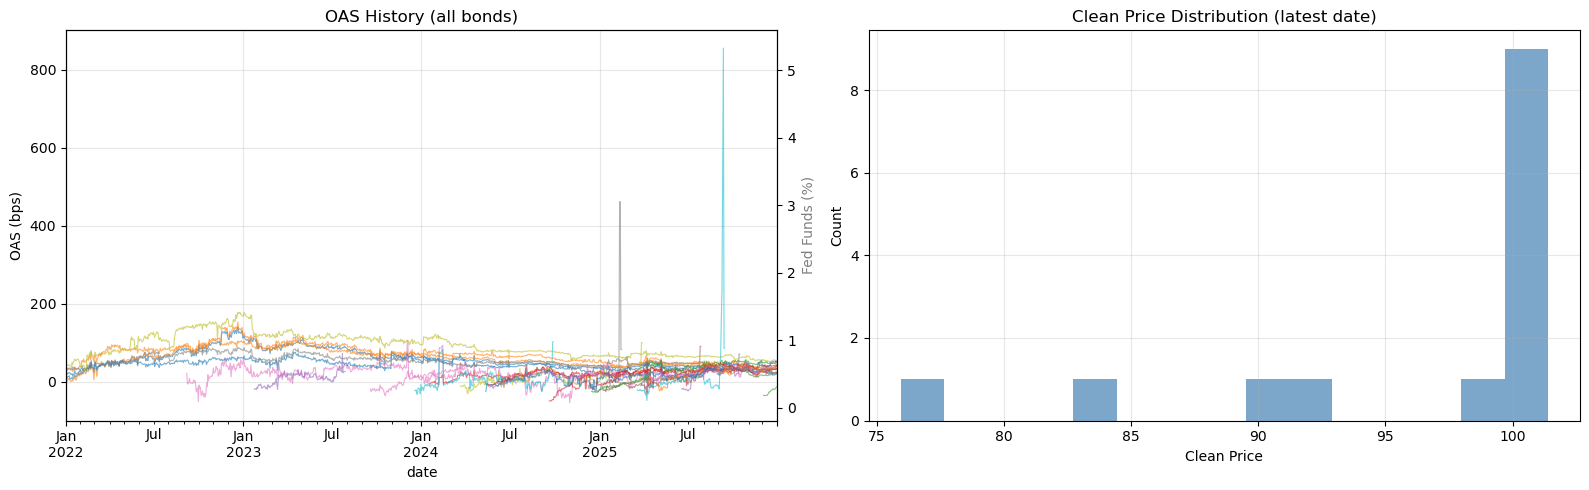

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# OAS time series
oas.plot(ax=axes[0], alpha=0.6, linewidth=0.8, legend=False)
axes[0].set_ylabel('OAS (bps)')
axes[0].set_title('OAS History (all bonds)')
axes[0].grid(True, alpha=0.3)

# Fed Funds rate for context
ff = rates.loc['2022':'2025', 'DFF']
ax2 = axes[0].twinx()
ax2.plot(ff.index, ff, 'k--', linewidth=1, alpha=0.4, label='Fed Funds')
ax2.set_ylabel('Fed Funds (%)', color='gray')

# Clean price distribution
clean.iloc[-1].dropna().hist(ax=axes[1], bins=15, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Clean Price')
axes[1].set_ylabel('Count')
axes[1].set_title('Clean Price Distribution (latest date)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Formulas

### Spread Decomposition (D.6.1)

$$\text{Z-spread} = \text{OAS} + \text{Option Cost}$$

The **Z-spread** prices the bond ignoring the embedded call. The **OAS** accounts for the issuer's call right. The difference is the **option cost**—the compensation for being short the call.

### Rolling Z-Score (Q2)

$$z_t = \frac{\text{OAS}_t - \overline{\text{OAS}}_{t-W:t}}{\sigma(\text{OAS}_{t-W:t})}$$

where $W$ is the rolling window (e.g., 60 trading days). A z-score above 1 means the bond is cheap relative to recent history; below $-1$ means expensive.

### Approximate Bond Return (Q2, Q3)

$$r_{\text{bond}} \approx -D_{\text{eff}} \times \frac{\Delta\text{OAS}}{10{,}000}$$

This spread-driven return approximation is used in Q2 for backtesting and refined in Q3 with carry and residual components.

### Return Decomposition (Q3)

For a bond with effective duration $D_{\text{eff}}$:

$$\text{Total Return} \approx \underbrace{\text{Coupon Accrual} - \text{Funding Cost}}_{\text{Carry}} + \underbrace{(-D_{\text{eff}} \times \Delta\text{OAS})}_{\text{Spread Return}} + \text{Residual}$$

The residual captures option repricing, curve moves, and model error.

where the carry component is:

$$\text{Carry (monthly)} = \frac{\text{Coupon}/12 - r_{\text{SOFR}} \times P_{\text{dirty}} / 12}{P_{\text{dirty}}}$$

and $r_{\text{SOFR}}$ is the annualized SOFR rate, $P_{\text{dirty}}$ is the dirty price at the start of the month.

### Call Moneyness (Q1)

$$\text{Call Moneyness} = \text{Coupon Rate} - s(T)$$

where $s(T)$ is the swap rate at the bond's maturity. Positive moneyness means the call is in the money (issuer has incentive to call).

## Questions


### Question 1: Cross-Section Anatomy

**Map the callable bond universe by its key characteristics and identify which bonds have the most expensive embedded calls.**

a) For each bond in the panel, compute the **call moneyness**: the difference between the bond's coupon rate and the current swap rate at the bond's maturity (interpolate the swap curve as needed). Positive moneyness means the call is in the money (the issuer has an incentive to call). Present the results in a table.

In [6]:
print("Last swap date:", swaps.index[-1])
print("Last OAS date:", oas.index[-1])
print("Last zsprd date:", zsprd.index[-1])
print("Last clean price date:", clean.index[-1])

Last swap date: 2025-06-30 00:00:00
Last OAS date: 2025-12-31 00:00:00
Last zsprd date: 2025-12-31 00:00:00
Last clean price date: 2025-12-31 00:00:00


`Since the quotes snapshot has up to March 3, 2026 but the oas time series and zsprd time series only has up until December 31, 2025 and the Swap rates only has data up until June 30 2025, we use June 30, 2025 for all for consistency.`

In [8]:
# Latest swap curve
latest_swap = swaps.iloc[-1].dropna()
swap_tenors = latest_swap.index.astype(float).values
swap_rates = latest_swap.values  # in percent, e.g. 4.5 means 4.5%

# Bond TTM and coupons
ttm = quotes.loc['TTM']
coupons = info.loc['Cpn Rate'] * 100  # convert to percent (0.05 -> 5.0)

# Compute moneyness for each bond
results = []
for bond in ttm.index:
    if pd.isna(ttm[bond]) or pd.isna(coupons[bond]):
        continue
    s_T = np.interp(ttm[bond], swap_tenors, swap_rates)
    m = coupons[bond] - s_T  # both in percent
    results.append({
        'Bond': bond,
        'Coupon (%)': coupons[bond],
        'TTM': round(ttm[bond], 2),
        'Swap Rate s(T) (%)': round(s_T, 4),
        'Moneyness (bps)': round(m * 100, 1)  # convert pct to bps
    })

moneyness_df = pd.DataFrame(results).set_index('Bond').sort_values('Moneyness (bps)', ascending=False)
display(moneyness_df)

,Coupon (%),TTM,Swap Rate s(T) (%),Moneyness (bps)
Bond,,,,
FHLB 5.5 12/28/28,5.500,2.83,3.4028,209.7
FHLMC 5.5 09/28/28,5.500,2.58,3.4135,208.6
FHLB 5.5 05/15/34,5.500,8.20,3.5950,190.5
FHLMC 5.25 01/28/30,5.250,3.91,3.3969,185.3
FHLB 5.25 03/28/29,5.250,3.07,3.3991,185.1
FHLB 5.375 12/15/34,5.375,8.79,3.6253,175.0
FHLB 5.125 05/15/29,5.125,3.20,3.3988,172.6
FHLB 5.25 05/15/35,5.250,9.20,3.6464,160.4
FHLB 5 01/15/30,5.000,3.88,3.3970,160.3


b) Compute the **option cost** for each bond: $\text{Option Cost} = \text{Z-spread} - \text{OAS}$ (both over the swap curve). Create a scatter plot of call moneyness vs. option cost. Describe the relationship. If implied vol data is available in the snapshot, compare it to option cost — how closely do they track across the moneyness spectrum?

In [16]:
common_bonds = zsprd.columns.intersection(oas.columns)
zsprd_latest = zsprd.iloc[-1] # Dec 31, 2025 from z-spread sheet
oas_latest = oas.iloc[-1] # Dec 31, 2025 from OAS sheet
option_cost_computed = zsprd_latest[common_bonds] - oas_latest[common_bonds]

implied_vol = quotes.loc['Implied Vol'].astype(float) # March 2026 snapshot from quotes sheet


q1b = pd.DataFrame({
    'Moneyness (bps)': moneyness_df['Moneyness (bps)'],
    'Option Cost (bps)': option_cost_computed,
    'Implied Vol': implied_vol
}).dropna(subset=['Option Cost (bps)'])

display(q1b)

,Moneyness (bps),Option Cost (bps),Implied Vol
FHLB 2 09/15/31,-145.5,29.411,21.022839
FHLB 4.25 03/28/30,85.1,51.310,24.465900
FHLB 4.25 12/28/28,84.7,35.801,25.266815
FHLB 4.875 09/28/28,146.1,6.368,23.623610
FHLB 5 09/28/32,149.2,471.678,NaN
FHLB 5.125 05/15/29,172.6,-0.458,23.538460
FHLB 5.25 05/15/35,160.4,110.764,19.325924
FHLB 5.375 12/15/34,175.0,67.868,20.898499
FHLB 5.5 05/15/34,190.5,60.779,19.929138
FHLMC 1 12/28/28,-240.3,18.906,22.676838


In [12]:
#compare to the option cost sheet
option_cost_sheet = opt_cost.iloc[-1] # Dec 31, 2025 from option cost sheet
comparison_df = pd.DataFrame({
    'Computed Option Cost (bps)': option_cost_computed,
    'Sheet Option Cost (bps)': option_cost_sheet
}).dropna()
display(comparison_df)

,Computed Option Cost (bps),Sheet Option Cost (bps)
FHLB 2 09/15/31,29.411,29.411
FHLB 4.25 03/28/30,51.310,51.310
FHLB 4.25 12/28/28,35.801,35.801
FHLB 4.875 09/28/28,6.368,6.368
FHLB 5 09/28/32,471.678,471.678
FHLB 5.125 05/15/29,-0.458,-0.458
FHLB 5.25 05/15/35,110.764,110.764
FHLB 5.375 12/15/34,67.868,67.868
FHLB 5.5 05/15/34,60.779,60.779
FHLMC 1 12/28/28,18.906,18.906


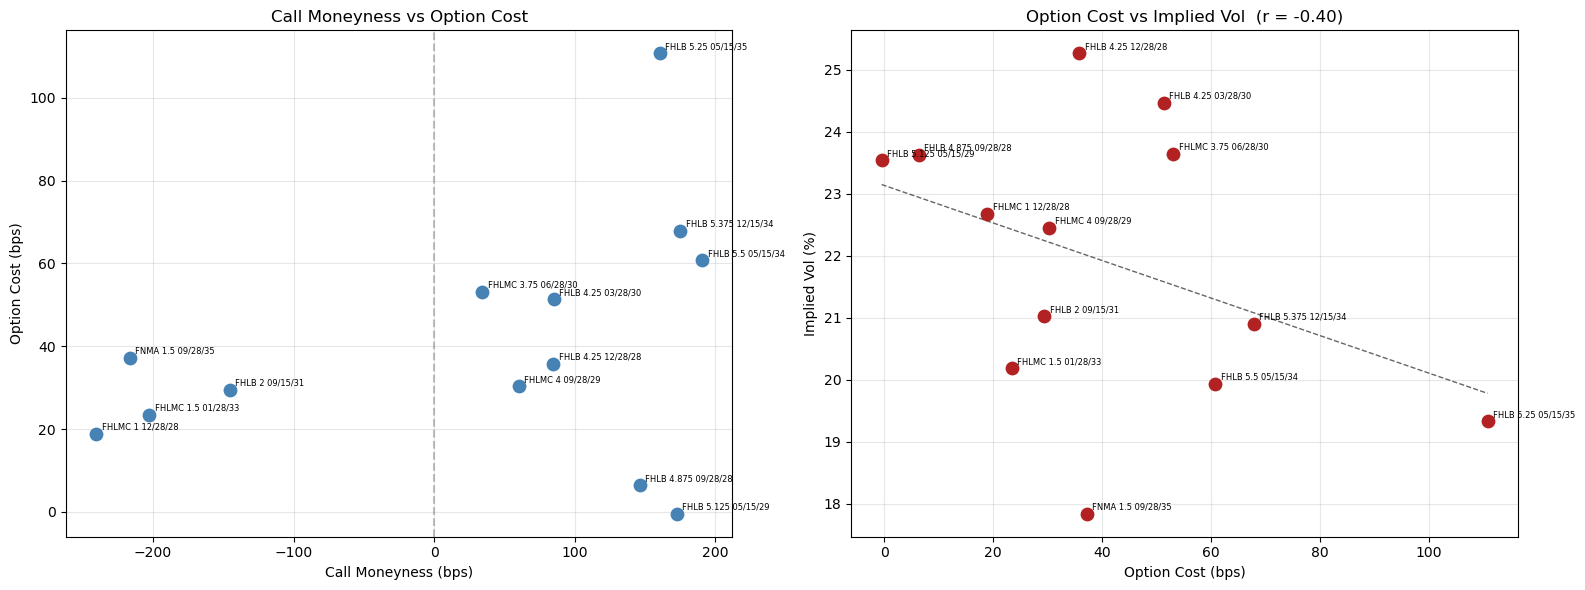

In [15]:
# Remove FHLB 5 09/28/32 outlier (anomalous option cost ~472 bps)
q1b_clean = q1b[q1b['Option Cost (bps)'] < 200]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Call Moneyness vs Option Cost
axes[0].scatter(q1b_clean['Moneyness (bps)'], q1b_clean['Option Cost (bps)'],
                color='steelblue', s=80, zorder=3)
for bond, row in q1b_clean.iterrows():
    axes[0].annotate(bond, (row['Moneyness (bps)'], row['Option Cost (bps)']),
                     fontsize=6, textcoords='offset points', xytext=(4, 3))
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Call Moneyness (bps)')
axes[0].set_ylabel('Option Cost (bps)')
axes[0].set_title('Call Moneyness vs Option Cost')
axes[0].grid(True, alpha=0.3)

# Plot 2: Option Cost vs Implied Vol
common = q1b_clean.dropna(subset=['Implied Vol'])
corr = common['Option Cost (bps)'].corr(common['Implied Vol'])
axes[1].scatter(common['Option Cost (bps)'], common['Implied Vol'],
                color='firebrick', s=80, zorder=3)
for bond, row in common.iterrows():
    axes[1].annotate(bond, (row['Option Cost (bps)'], row['Implied Vol']),
                     fontsize=6, textcoords='offset points', xytext=(4, 3))
m, b = np.polyfit(common['Option Cost (bps)'], common['Implied Vol'], 1)
x_line = np.linspace(common['Option Cost (bps)'].min(), common['Option Cost (bps)'].max(), 100)
axes[1].plot(x_line, m * x_line + b, 'k--', linewidth=1, alpha=0.6)
axes[1].set_xlabel('Option Cost (bps)')
axes[1].set_ylabel('Implied Vol (%)')
axes[1].set_title(f'Option Cost vs Implied Vol  (r = {corr:.2f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observation:** 
- Call Moneyness vs Option Cost (left): Option cost is broadly higher for ITM bonds (moneyness > 0) than OTM bonds (moneyness < 0), consistent with theory that the issuer's call has intrinsic value when coupon exceeds current swap rates. However, the relationship is non-monotonic since some deeply ITM bonds (FHLB 4.875, FHLB 5.125) show near-zero option cost because they are priced almost entirely to their imminent call date, leaving no remaining optionality to price. OTM bonds cluster at 20-40 bps, reflecting pure time value with no intrinsic component.

- Option Cost vs Implied Vol (right): The negative correlation (r = -0.40) is counterintuitive but explainable. Implied vol is relatively uniform across bonds (18-26%), while option cost varies widely based on moneyness and structure. The deeply ITM short-duration bonds that have the highest option costs also have the lowest implied vols, hence, the call is near-certain to be exercised so there is little uncertainty to price, compressing implied vol even as option cost remains high. This shows that implied vol and option cost are not interchangeable. vol measures rate uncertainty, option cost measures the full economic value of the call including intrinsic value.

---

c) Create a visualization showing how **effective duration** and **effective convexity** vary across the panel. Which bonds exhibit the most negative convexity? How does this relate to call moneyness?


In [20]:
# Q1c - effective duration and convexity from quotes snapshot
eff_dur = quotes.loc['Eff Duration'].astype(float)
eff_conv = quotes.loc['Eff Convexity'].astype(float)

q1c = pd.DataFrame({
    'Moneyness (bps)': moneyness_df['Moneyness (bps)'],
    'Eff Duration': eff_dur,
    'Eff Convexity': eff_conv
}).dropna().sort_values('Moneyness (bps)')

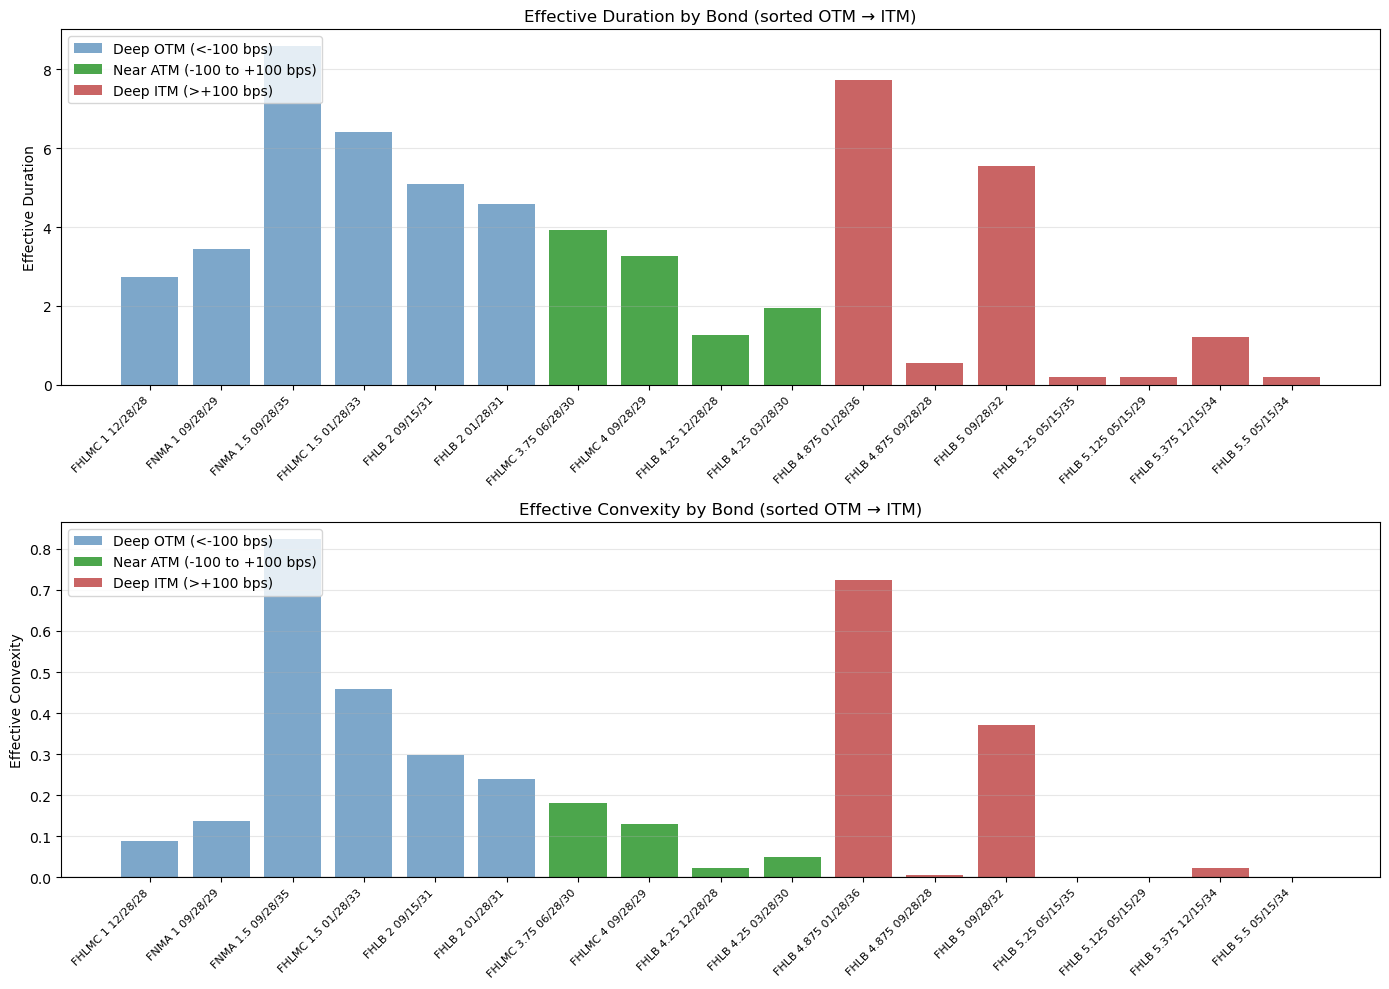

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Duration
colors_dur = ['steelblue' if m < -100 else 'green' if m < 100 else 'firebrick' 
               for m in q1c['Moneyness (bps)']]
axes[0].bar(range(len(q1c)), q1c['Eff Duration'], color=colors_dur, alpha=0.7)
axes[0].set_xticks(range(len(q1c)))
axes[0].set_xticklabels(q1c.index, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Effective Duration')
axes[0].set_title('Effective Duration by Bond (sorted OTM → ITM)')
axes[0].grid(True, alpha=0.3, axis='y')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='Deep OTM (<-100 bps)'),
                   Patch(facecolor='green', alpha=0.7, label='Near ATM (-100 to +100 bps)'),
                   Patch(facecolor='firebrick', alpha=0.7, label='Deep ITM (>+100 bps)')]
axes[0].legend(handles=legend_elements, loc='upper left')

# Convexity
axes[1].bar(range(len(q1c)), q1c['Eff Convexity'], color=colors_dur, alpha=0.7)
axes[1].set_xticks(range(len(q1c)))
axes[1].set_xticklabels(q1c.index, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Effective Convexity')
axes[1].set_title('Effective Convexity by Bond (sorted OTM → ITM)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

**Observation:**

Effective Duration declines broadly as moneyness increases from OTM to ITM, consistent with theory. Deep OTM bonds exhibit the highest durations, ranging from 2.7 to 7.3 years. Since the embedded call is nearly worthless for these bonds, the market prices them to maturity like normal bonds, resulting in full duration exposure. Near-ATM bonds show moderate durations reflecting market uncertainty about whether the bond will be called or held to maturity. Deep ITM bonds show very low durations of 0.19–0.54 years, as the market prices them almost entirely to the nearest call date.

`Two ITM bonds stand out as exceptions: FHLB 4.875 01/28/36 (duration 7.7) and FHLB 5 09/28/32 (duration 5.5).` Despite being in-the-money, their long maturities (2036 and 2032 respectively) introduce sufficient rate uncertainty that the market does not fully price them to call, leaving duration elevated. This illustrates that effective duration for callable bonds is driven by two competing forces of moneyness pushing duration down and time to maturity pushing it up.

Effective Convexity follows a similar pattern, highest for OTM bonds and approaching zero for deeply ITM bonds. Notably, no bond in the panel exhibits negative convexity, which theory predicts for deeply ITM callables. This could be due to the fact some of the deeply ITM bonds could already past or near their first call date, meaning the market prices them as very short maturity instruments; a bond priced to an impending call has near-zero convexity purely from duration math.

---

d) Group bonds into three categories: deep OTM callables (moneyness < −100 bps), near-ATM callables (−100 to +100 bps), and deep ITM callables (moneyness > +100 bps), or justify alternative cutoffs. Summarize how OAS, option cost, duration, and convexity differ across groups.

In [ ]:
# Add OAS to the dataframe
q1d = pd.DataFrame({
    'Moneyness (bps)': moneyness_df['Moneyness (bps)'],
    'OAS (bps)': oas_latest,
    'Option Cost (bps)': option_cost_computed,
    'Eff Duration': eff_dur,
    'Eff Convexity': eff_conv
})

# Assign moneyness groups using project cutoffs
def assign_group(m):
    if m < -100:
        return 'Deep OTM'
    elif m <= 100:
        return 'Near ATM'
    else:
        return 'Deep ITM'

q1d['Group'] = q1d['Moneyness (bps)'].apply(assign_group)

# Summary table
summary = q1d.groupby('Group')[['OAS (bps)', 'Option Cost (bps)', 
                                  'Eff Duration', 'Eff Convexity']].mean().round(2)

# Reorder rows logically
summary = summary.reindex(['Deep OTM', 'Near ATM', 'Deep ITM'])
print(summary)
print("\nBond counts per group:")
print(q1d['Group'].value_counts())

          OAS (bps)  Option Cost (bps)  Eff Duration  Eff Convexity
Group                                                              
Deep OTM      30.64              27.23          5.14           0.34
Near ATM      16.54              42.63          2.60           0.10
Deep ITM      42.84             119.50          2.23           0.16

Bond counts per group:
Group
Deep ITM    16
Deep OTM     6
Near ATM     4
Name: count, dtype: int64


**Observation:**

1. Deep OTM (moneyness < -100 bps, 6 bonds): Highest effective duration (5.1 years) and lowest option cost (27 bps), the call is nearly worthless so these bonds behave like vanilla bonds, carrying full rate exposure. OAS of 31 bps reflects 
genuine credit/liquidity premium with minimal option noise.

2. Near ATM (-100 to +100 bps, 4 bonds): Lowest OAS (17 bps) despite moderate option  cost (43 bps), the bondholder is giving up the most spread to compensate for optionality uncertainty. Duration compresses to 2.6 years as the market prices in some probability of call exercise.

3. Deep ITM (moneyness > +100 bps, 16 bonds): Highest option cost by far (120 bps) reflecting large intrinsic call value, and lowest duration (2.2 years) as the market prices these almost entirely to the call date. The high OAS (43 bps) is 
counterintuitive but reflects genuine cheapness after stripping out the large option cost. These bonds offer real spread compensation even on an option-adjusted basis.

Convexity declines from OTM to ITM, consistent with theory — deeply ITM callables have near-zero convexity as their price is anchored to the call price regardless of rate direction.

---

(e) Which moneyness group looks most attractive for a spread strategy, and why?

**Answer:** 

Deep OTM bonds (low-coupon, moneyness < -100 bps) are most attractive for a spread strategy for following reasons:

1. Longest effective duration (5-9 years), so more P&L per basis point of OAS compression, making the spread signal economically meaningful.

2. Lowest and most stable option cost (20-40 bps, pure time value). OAS closely tracks Z-spread, so the z-score signal is clean and not contaminated by option repricing noise.

3. Predictable behavior — since the call is far OTM, the bond trades like a vanilla bond. OAS mean-reversion is driven by credit and liquidity factors rather than volatile implied vol swings.

Near-ATM bonds are the least attractive despite having meaningful option cost. The signal is noisiest precisely where optionality is most sensitive to rate moves, making false signals most likely. Deep ITM bonds have compressed duration and near-certain call exercise, leaving little spread to capture.

---

### Question 2: OAS Signal and Backtest

**Construct a mean-reversion strategy using OAS z-scores and backtest it over 2022–2025.**

In [24]:
print("Bonds with missing Eff Duration:")
print(eff_dur[eff_dur.isna()])
print(f"\nBonds with OAS data: {oas.shape[1]}")
print(f"Bonds with duration: {eff_dur.dropna().shape[0]}")

Bonds with missing Eff Duration:
FHLB 4.75 06/15/28    NaN
FHLB 5 01/15/30       NaN
FHLB 5 12/15/27       NaN
FHLB 5.25 03/28/29    NaN
FHLB 5.5 12/28/28     NaN
FHLMC 4.75 01/28/28   NaN
FHLMC 5.25 01/28/30   NaN
FHLMC 5.5 09/28/28    NaN
FNMA 5 03/15/30       NaN
Name: Eff Duration, dtype: float64

Bonds with OAS data: 25
Bonds with duration: 17



a) For each bond, compute the **rolling OAS z-score** using a 60-trading-day window:

$$z_t = \frac{\text{OAS}_t - \overline{\text{OAS}}_{t-W:t}}{\sigma(\text{OAS}_{t-W:t})}$$

Plot the z-score time series for 3–4 representative bonds (one from each moneyness group).

In [27]:
# Rolling OAS z-scores
W = 60  # rolling window

oas_zscore = (oas - oas.rolling(W).mean()) / oas.rolling(W).std()
print(oas_zscore.shape)

(1043, 25)


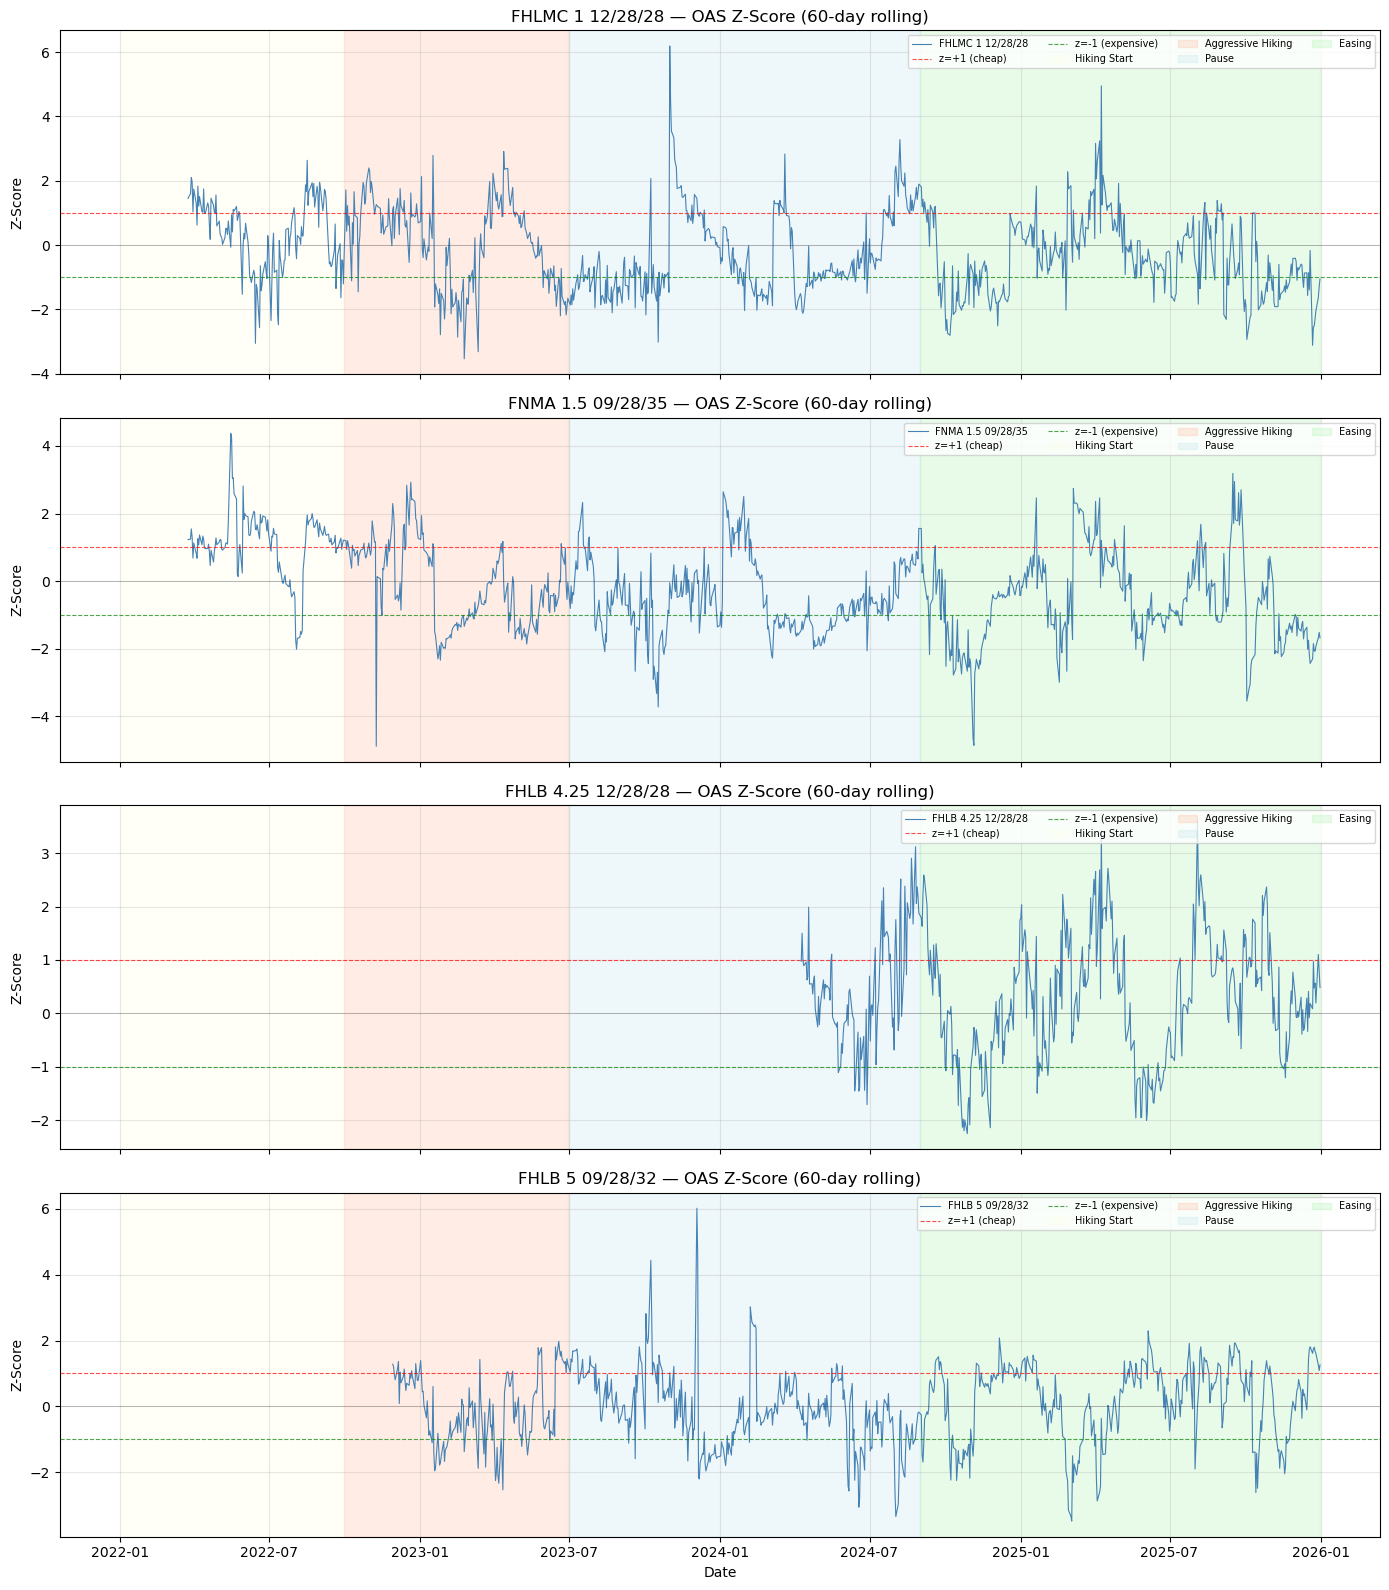

In [ ]:
rep_bonds = ['FHLMC 1 12/28/28', 'FNMA 1.5 09/28/35', 
             'FHLB 4.25 12/28/28', 'FHLB 5 09/28/32']

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Regime shading
regimes = [
    ('2022-01-01', '2022-09-30', 'Hiking Start', 'lightyellow'),
    ('2022-10-01', '2023-06-30', 'Aggressive Hiking', 'lightsalmon'),
    ('2023-07-01', '2024-08-31', 'Pause', 'lightblue'),
    ('2024-09-01', '2025-12-31', 'Easing', 'lightgreen')
]

for ax, bond in zip(axes, rep_bonds):
    # Plot z-score
    ax.plot(oas_zscore.index, oas_zscore[bond], 
            linewidth=0.8, color='steelblue', label=bond)
    
    # Threshold lines
    ax.axhline(1, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='z=+1 (cheap)')
    ax.axhline(-1, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label='z=-1 (expensive)')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Regime shading
    for start, end, label, color in regimes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), 
                   alpha=0.2, color=color, label=label)
    
    ax.set_ylabel('Z-Score')
    ax.set_title(f'{bond} — OAS Z-Score (60-day rolling)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=7, ncol=4)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

**Observation:**

1. OTM bonds (FHLMC 1, FNMA 1.5) show frequent, large z-score excursions throughout the full sample with clear mean-reversion. These generate the most reliable signals. 
2. The largest spikes occur during aggressive hiking (late 2022 to mid 2023) as low-coupon bonds cheapened sharply then normalized. 
3. Near-ATM (FHLB 4.25) and ITM (FHLB 5) bonds enter the panel late (2023-2024) with noisier early z-scores reflecting price discovery on newly issued bonds rather than genuine mispricings. 
4. Consistent with Q1e, OTM bonds provide the cleanest trading signals.

---

b) Design a **long/short strategy**: go long bonds with $z > 1$ (OAS is wide relative to history, bond is cheap) and short bonds with $z < -1$ (OAS is tight, bond is expensive). Weight positions by equal notional within each leg. Rebalance positions monthly.

**Strategy**: 

1. At each month-end, bonds with OAS z-score > 1 are flagged as cheap (long) and bonds with z-score < -1 are flagged as expensive (short). 
2. Positions will be equal weighted within each leg independently i.e. if 3 bonds are long, each gets 1/3 
weight; the short leg is sized the same way. 
3. Signals are lagged by one month, meaning the z-score observed at end of month t drives the position held during 
month t+1. 
4. Only the 16 bonds with both OAS history and a valid snapshot duration are eligible for the strategy.

In [29]:
# Get month-end dates
monthly_oas = oas.resample('ME').last()
monthly_zscore = oas_zscore.resample('ME').last()

print("Monthly dates:", len(monthly_oas))

Monthly dates: 48


In [30]:
# Bonds usable for strategy
usable_bonds = eff_dur.dropna().index.intersection(oas.columns)
print("Usable bonds:", usable_bonds.tolist())
print("Count:", len(usable_bonds))

Usable bonds: ['FHLB 2 01/28/31', 'FHLB 2 09/15/31', 'FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLB 5 09/28/32', 'FHLMC 1 12/28/28', 'FHLMC 1.5 01/28/33', 'FHLMC 3.75 06/28/30', 'FHLMC 4 09/28/29', 'FNMA 1 09/28/29', 'FNMA 1.5 09/28/35', 'FHLB 4.875 09/28/28', 'FHLB 5.125 05/15/29', 'FHLB 5.25 05/15/35', 'FHLB 5.375 12/15/34', 'FHLB 5.5 05/15/34']
Count: 16


In [31]:
# Filter to usable bonds only
monthly_zscore_usable = monthly_zscore[usable_bonds]

# Generate signals: 1=long, -1=short, 0=no position
signals = pd.DataFrame(0, index=monthly_zscore_usable.index, 
                        columns=monthly_zscore_usable.columns)
signals[monthly_zscore_usable > 1] = 1
signals[monthly_zscore_usable < -1] = -1

print("Signal counts per month (non-zero positions):")
print(signals.abs().sum(axis=1).head(20))
print("\nSample signals:")
print(signals[signals != 0].dropna(how='all').head(10))

Signal counts per month (non-zero positions):
date
2022-01-31    0
2022-02-28    0
2022-03-31    2
2022-04-30    3
2022-05-31    4
2022-06-30    2
2022-07-31    1
2022-08-31    4
2022-09-30    3
2022-10-31    6
2022-11-30    6
2022-12-31    1
2023-01-31    7
2023-02-28    6
2023-03-31    3
2023-04-30    5
2023-05-31    4
2023-06-30    4
2023-07-31    2
2023-08-31    4
Freq: ME, dtype: int64

Sample signals:
            FHLB 2 01/28/31  FHLB 2 09/15/31  FHLB 4.25 03/28/30  \
date                                                               
2022-03-31              NaN              NaN                 NaN   
2022-04-30              1.0              1.0                 NaN   
2022-05-31              1.0              1.0                 NaN   
2022-06-30              NaN              NaN                 NaN   
2022-07-31              1.0              NaN                 NaN   
2022-08-31              1.0              1.0                 NaN   
2022-09-30              NaN              1.0 

In [32]:
# Equal weight within long and short legs separately
long_signals = signals.copy()
long_signals[signals != 1] = 0

short_signals = signals.copy()
short_signals[signals != -1] = 0

# Count active positions per leg per month
n_long = long_signals.sum(axis=1)
n_short = short_signals.abs().sum(axis=1)

# Equal weight positions
long_weights = long_signals.div(n_long.replace(0, np.nan), axis=0).fillna(0)
short_weights = short_signals.div(n_short.replace(0, np.nan), axis=0).fillna(0)

# Combined positions (+ve = long, -ve = short)
positions = long_weights + short_weights

print("Sample positions (should sum to 1 for long leg, -1 for short leg):")
print("Long leg sum:", long_weights.sum(axis=1).head(10))
print("Short leg sum:", short_weights.sum(axis=1).head(10))

Sample positions (should sum to 1 for long leg, -1 for short leg):
Long leg sum: date
2022-01-31    0.0
2022-02-28    0.0
2022-03-31    1.0
2022-04-30    1.0
2022-05-31    1.0
2022-06-30    1.0
2022-07-31    1.0
2022-08-31    1.0
2022-09-30    1.0
2022-10-31    1.0
Freq: ME, dtype: float64
Short leg sum: date
2022-01-31    0.0
2022-02-28    0.0
2022-03-31    0.0
2022-04-30    0.0
2022-05-31    0.0
2022-06-30    0.0
2022-07-31    0.0
2022-08-31    0.0
2022-09-30   -1.0
2022-10-31    0.0
Freq: ME, dtype: float64



c) Compute monthly returns for the strategy. Approximate each bond's monthly return as $-D_{\text{eff}} \times \Delta\text{OAS} / 10{,}000$, where $D_{\text{eff}}$ is the snapshot effective duration and $\Delta\text{OAS}$ is the monthly OAS change in basis points. Report:
   - Annualized return
   - Annualized volatility
   - Sharpe ratio
   - Maximum drawdown
   - Hit rate (% of months with positive P&L when a position is on)


In [33]:
# Q2c - Monthly returns
# Monthly OAS changes (in bps)
monthly_oas_usable = oas[usable_bonds].resample('ME').last()
delta_oas = monthly_oas_usable.diff()  # month-over-month change in bps

# Effective duration (constant snapshot)
dur = eff_dur[usable_bonds]

# Bond-level returns: -D_eff * delta_OAS / 10000
bond_returns = -dur * delta_oas / 10000

print("Sample bond returns:")
print(bond_returns.head(10).round(4))

Sample bond returns:
            FHLB 2 01/28/31  FHLB 2 09/15/31  FHLB 4.25 03/28/30  \
date                                                               
2022-01-31              NaN              NaN                 NaN   
2022-02-28          -0.0074          -0.0061                 NaN   
2022-03-31          -0.0021          -0.0077                 NaN   
2022-04-30          -0.0053          -0.0052                 NaN   
2022-05-31          -0.0021          -0.0033                 NaN   
2022-06-30          -0.0020          -0.0032                 NaN   
2022-07-31          -0.0029          -0.0024                 NaN   
2022-08-31          -0.0061          -0.0090                 NaN   
2022-09-30          -0.0003          -0.0009                 NaN   
2022-10-31          -0.0096          -0.0112                 NaN   

            FHLB 4.25 12/28/28  FHLB 5 09/28/32  FHLMC 1 12/28/28  \
date                                                                
2022-01-31              

In [34]:
# Strategy return = positions (lagged 1 month) * bond returns
# Lag positions by 1 month — signal at end of month t drives return in month t+1
positions_lagged = positions.shift(1)

# Separate long and short leg returns
long_ret = (long_weights.shift(1) * bond_returns).sum(axis=1)
short_ret = (short_weights.shift(1) * bond_returns).sum(axis=1)

# Combined strategy return
strategy_ret = long_ret + short_ret

print("\nStrategy returns:")
print(strategy_ret.dropna().head(10).round(4))


Strategy returns:
date
2022-01-31    0.0000
2022-02-28    0.0000
2022-03-31    0.0000
2022-04-30    0.0006
2022-05-31   -0.0109
2022-06-30   -0.0053
2022-07-31    0.0139
2022-08-31   -0.0061
2022-09-30   -0.0020
2022-10-31   -0.0033
Freq: ME, dtype: float64


In [38]:
# Make sure to filter properly
active_months = strategy_ret[strategy_ret != 0].dropna()

ann_return = active_months.mean() * 12
ann_vol = active_months.std() * np.sqrt(12)
sharpe = ann_return / ann_vol

cumulative = (1 + active_months).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()

hit_rate = (active_months > 0).sum() / len(active_months)

print(f"Annualized Return:     {ann_return:.2%}")
print(f"Annualized Volatility: {ann_vol:.2%}")
print(f"Sharpe Ratio:          {sharpe:.2f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")
print(f"Hit Rate:              {hit_rate:.2%}")
print(f"Active months:         {len(active_months)}")

Annualized Return:     2.23%
Annualized Volatility: 2.92%
Sharpe Ratio:          0.77
Maximum Drawdown:      -1.67%
Hit Rate:              56.82%
Active months:         44


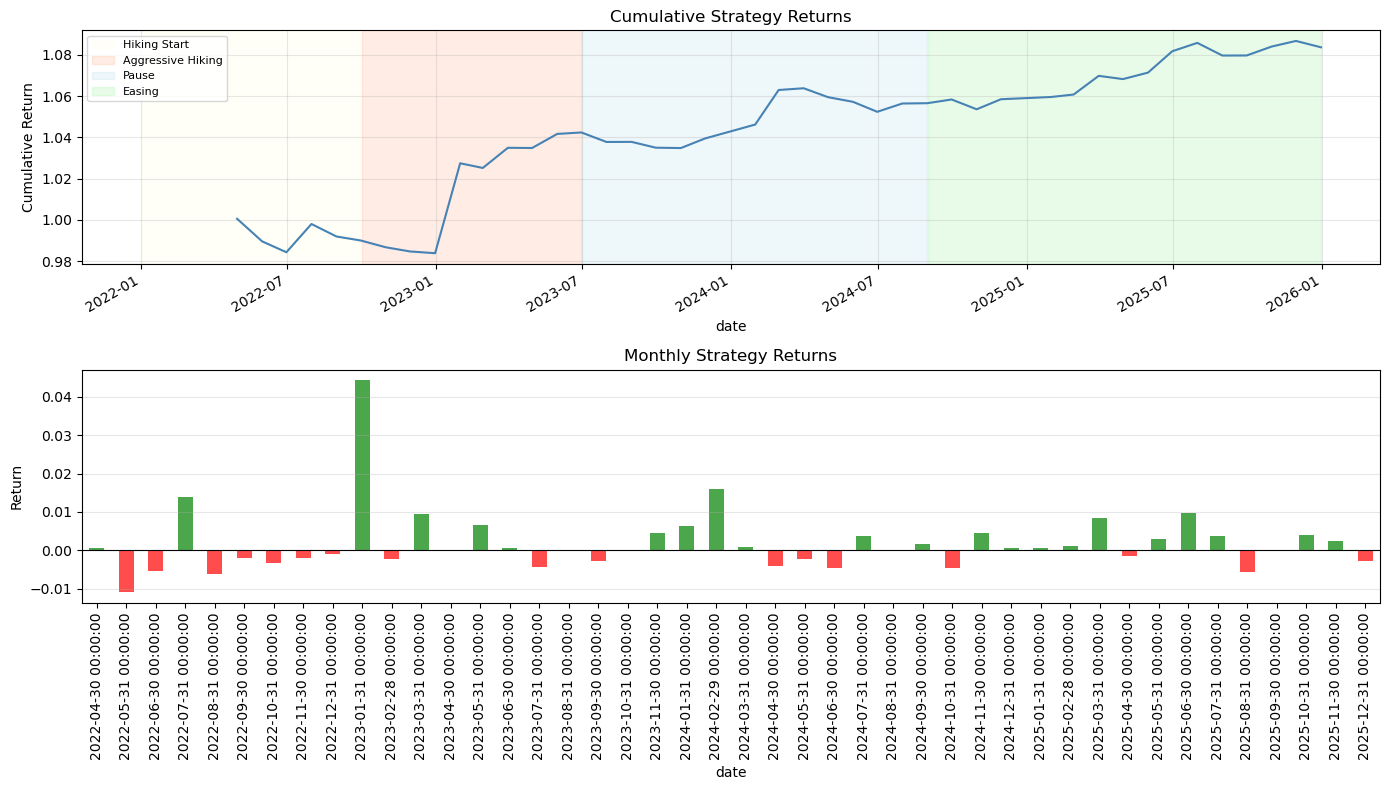

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Cumulative returns
cumulative.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Cumulative Strategy Returns')
axes[0].set_ylabel('Cumulative Return')
axes[0].grid(True, alpha=0.3)

# Add regime shading
for start, end, label, color in regimes:
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.2, color=color, label=label)
axes[0].legend(loc='upper left', fontsize=8)

# Monthly returns bar chart
active_months.plot(kind='bar', ax=axes[1], 
                   color=['green' if x > 0 else 'red' for x in active_months],
                   alpha=0.7)
axes[1].set_title('Monthly Strategy Returns')
axes[1].set_ylabel('Return')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Observation:**

1. The strategy earns 2.23% annualized with a Sharpe of 0.77 and max drawdown of -1.67%. 
2. Performance looks uneven across regimes. The hiking start period produces the most volatile monthly returns as rate shocks dominate spread moves, while the pause and easing periods show steadier positive months consistent with reliable 
OAS mean-reversion. 
3. January 2023 stands out as the single largest monthly return, driven by sharp OAS compression as the hiking cycle neared its peak. 
4. The hit rate of 57% confirms the signal is right more often than not when active.

---

d) Test the sensitivity of results to the rolling window length (try 30, 60, and 90 days) and the z-score threshold (try 1.0 and 1.5). Which combination produces the best risk-adjusted returns? Discuss the trade-off between signal frequency and signal quality.


In [40]:
def run_strategy(oas, eff_dur, usable_bonds, window, threshold):
    # Rolling z-score
    zscore = (oas - oas.rolling(window).mean()) / oas.rolling(window).std()
    monthly_zscore = zscore[usable_bonds].resample('ME').last()
    
    # Signals
    signals = pd.DataFrame(0, index=monthly_zscore.index, 
                           columns=monthly_zscore.columns)
    signals[monthly_zscore > threshold] = 1
    signals[monthly_zscore < -threshold] = -1
    
    # Positions
    long_s = signals.copy()
    long_s[signals != 1] = 0
    short_s = signals.copy()
    short_s[signals != -1] = 0
    
    n_long = long_s.sum(axis=1)
    n_short = short_s.abs().sum(axis=1)
    
    long_w = long_s.div(n_long.replace(0, np.nan), axis=0).fillna(0)
    short_w = short_s.div(n_short.replace(0, np.nan), axis=0).fillna(0)
    
    # Returns
    monthly_oas = oas[usable_bonds].resample('ME').last()
    delta_oas = monthly_oas.diff()
    dur = eff_dur[usable_bonds]
    bond_ret = -dur * delta_oas / 10000
    
    long_ret = (long_w.shift(1) * bond_ret).sum(axis=1)
    short_ret = (short_w.shift(1) * bond_ret).sum(axis=1)
    strat_ret = long_ret + short_ret
    
    # Metrics
    active = strat_ret[strat_ret != 0].dropna()
    if len(active) == 0:
        return None
        
    ann_ret = active.mean() * 12
    ann_vol = active.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    
    cumulative = (1 + active).cumprod()
    rolling_max = cumulative.cummax()
    max_dd = ((cumulative - rolling_max) / rolling_max).min()
    hit_rate = (active > 0).sum() / len(active)
    
    return {
        'Window': window,
        'Threshold': threshold,
        'Ann Return': ann_ret,
        'Ann Vol': ann_vol,
        'Sharpe': sharpe,
        'Max Drawdown': max_dd,
        'Hit Rate': hit_rate,
        'Active Months': len(active)
    }

# Run all 6 combinations
results = []
for window in [30, 60, 90]:
    for threshold in [1.0, 1.5]:
        r = run_strategy(oas, eff_dur, usable_bonds, window, threshold)
        if r:
            results.append(r)

results_df = pd.DataFrame(results).set_index(['Window', 'Threshold'])
display(results_df.round(4))

Ann Return  Ann Vol  Sharpe  Max Drawdown  Hit Rate  \
Window Threshold                                                        
30     1.0            0.0159   0.0264  0.6023       -0.0344    0.5581   
       1.5            0.0030   0.0167  0.1819       -0.0165    0.4545   
60     1.0            0.0223   0.0292  0.7661       -0.0167    0.5682   
       1.5            0.0191   0.0198  0.9672       -0.0137    0.6250   
90     1.0            0.0207   0.0289  0.7165       -0.0207    0.5116   
       1.5            0.0291   0.0320  0.9080       -0.0140    0.6061   

                  Active Months  
Window Threshold                 
30     1.0                   43  
       1.5                   33  
60     1.0                   44  
       1.5                   32  
90     1.0                   43  
       1.5                   33

A lower threshold (z > 1.0) generates more signals (43-44 active months) but includes marginal mispricings that revert slowly or not at all, increasing volatility without proportionally increasing returns. 

A higher threshold (z > 1.5) filters to only the most extreme OAS dislocations (32-33 active months), where mean-reversion is faster and more reliable. The cost is fewer trades and longer periods with no position.

`The 60-day window with 1.5 threshold produces the best risk-adjusted returns (Sharpe 0.97)`, long enough to filter noise but short enough to remain responsive to genuine mispricings. 

`The 90-day/1.5 combination produces higher raw returns but with more volatility`, suggesting the longer window occasionally misses the optimal entry point.

`Trade-off`:

Window trade-off: A shorter window (W=30) adapts quickly to recent OAS levels but sets a low bar — minor noise crosses the threshold generating low-quality signals (Sharpe 0.60, max drawdown -3.4%). A longer window (W=90) builds a more stable historical anchor, filtering out transient moves and identifying only genuine dislocations, but risks being slow to adapt when the OAS level shifts structurally across regimes.

Threshold trade-off: A lower threshold (1.0) generates more signals (43-44 active months) but includes marginal mispricings that revert slowly or not at all, increasing volatility without proportionally increasing returns. A higher threshold (1.5) restricts trades to the most extreme dislocations (32-33 active months) where mean-reversion is faster and more reliable — hit rates improve from ~51-57% to ~45-63% and vol drops significantly. The cost is fewer active months and longer periods with no position.

The W=30/threshold=1.5 combination is the exception — cutting both window and raising threshold simultaneouslyover-filters the signal, leaving too few high-quality opportunities (Sharpe collapses to 0.18). This confirms that window length and threshold interact: a short window needs a lower threshold to generate enough signals, while a longer window earns the right to be more selective.

### Question 3: Return Decomposition

**Decompose monthly strategy returns into carry, spread compression, and residual components.**

*Note: This question uses the subset of bonds with dirty price data (15 bonds). Effective duration is available as a snapshot in the `quotes` sheet—use it as a constant approximation, or compute numerical duration from price data if you prefer.*

In [41]:
# Check 15 bonds with price data
print("Bonds with dirty prices:", dirty.columns.tolist())
print("Price date range:", dirty.index[0].date(), "to", dirty.index[-1].date())

# Check SOFR column name
print("\nRate columns:", rates.columns.tolist())
print(rates.head())

Bonds with dirty prices: ['FHLB 2 01/28/31', 'FHLB 2 09/15/31', 'FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLB 5 09/28/32', 'FHLMC 1 12/28/28', 'FHLMC 1.5 01/28/33', 'FHLMC 3.75 06/28/30', 'FHLMC 4 09/28/29', 'FNMA 1.5 09/28/35', 'FHLB 5.5 05/15/34', 'FHLB 5.25 05/15/35', 'FHLB 5.375 12/15/34', 'FHLB 4.875 09/28/28', 'FHLB 5.125 05/15/29']
Price date range: 2022-01-03 to 2025-12-31

Rate columns: ['DTB3', 'DFF', 'SOFR']
            DTB3   DFF  SOFR
date                        
2018-01-01   NaN  1.33   NaN
2018-01-02  1.42  1.42   NaN
2018-01-03  1.39  1.42   NaN
2018-01-04  1.39  1.42   NaN
2018-01-05  1.37  1.42   NaN


In [42]:
# Bonds with both dirty prices AND duration
price_bonds = dirty.columns.tolist()
q3_bonds = [b for b in price_bonds if b in eff_dur.dropna().index]
print("Bonds with prices AND duration:", q3_bonds)
print("Count:", len(q3_bonds))

# Check SOFR availability for sample period
sofr = rates.loc['2022':'2025', 'SOFR']
print("\nSOFR NaN count:", sofr.isna().sum())
print("SOFR sample:", sofr.head())

Bonds with prices AND duration: ['FHLB 2 01/28/31', 'FHLB 2 09/15/31', 'FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLB 5 09/28/32', 'FHLMC 1 12/28/28', 'FHLMC 1.5 01/28/33', 'FHLMC 3.75 06/28/30', 'FHLMC 4 09/28/29', 'FNMA 1.5 09/28/35', 'FHLB 5.5 05/15/34', 'FHLB 5.25 05/15/35', 'FHLB 5.375 12/15/34', 'FHLB 4.875 09/28/28', 'FHLB 5.125 05/15/29']
Count: 15

SOFR NaN count: 464
SOFR sample: date
2022-01-01     NaN
2022-01-02     NaN
2022-01-03    0.05
2022-01-04    0.05
2022-01-05    0.05
Name: SOFR, dtype: float64


In [43]:
# Check for bonds that disappear mid-sample
for bond in q3_bonds:
    last_price = dirty[bond].last_valid_index()
    print(f"{bond}: last price date = {last_price.date()}")

FHLB 2 01/28/31: last price date = 2022-12-02
FHLB 2 09/15/31: last price date = 2025-12-31
FHLB 4.25 03/28/30: last price date = 2025-12-31
FHLB 4.25 12/28/28: last price date = 2025-12-31
FHLB 5 09/28/32: last price date = 2025-12-31
FHLMC 1 12/28/28: last price date = 2025-12-31
FHLMC 1.5 01/28/33: last price date = 2025-12-31
FHLMC 3.75 06/28/30: last price date = 2025-12-31
FHLMC 4 09/28/29: last price date = 2025-12-31
FNMA 1.5 09/28/35: last price date = 2025-12-31
FHLB 5.5 05/15/34: last price date = 2025-12-31
FHLB 5.25 05/15/35: last price date = 2025-12-31
FHLB 5.375 12/15/34: last price date = 2025-12-31
FHLB 4.875 09/28/28: last price date = 2025-12-31
FHLB 5.125 05/15/29: last price date = 2025-12-31


Of the 15 bonds with dirty price data, 14 have complete price histories through December 31, 2025. One bond, FHLB 2 01/28/31, exits the panel after December 2, 2022 — likely called or rendered illiquid during the aggressive hiking period — and is excluded from the Q3 return decomposition to avoid survivorship bias.

The broader panel of 25 bonds contains 9 additional bonds with no snapshot duration analytics, all high-coupon issues (4.75%+) that were previously called by their issuers. These bonds are excluded from the Q2 strategy and Q3 decomposition. While their exclusion avoids the most acute form of survivorship bias, where a bond generates a long signal immediately before being called at par. It also means the backtest underrepresents the ITM callable universe. Strategy performance reported here should be interpreted with this limitation in mind, as the surviving bond sample skews toward lower-coupon, longer-duration instruments that behaved more like vanilla bonds during the 2022–2025 rate cycle.


a) For each bond with dirty price data, compute monthly returns. Decompose each bond's return into:

   - **Carry**: coupon accrual minus funding cost (use SOFR as the funding rate)
   - **Spread return**: $-D_{\text{eff}} \times \Delta \text{OAS}$, where $D_{\text{eff}}$ is effective duration and $\Delta \text{OAS}$ is the monthly change in OAS
   - **Residual**: total return minus carry minus spread return (captures option repricing, curve moves, model error)

In [44]:
# Q3a - Rerun with clean bond list
q3_bonds_clean = [b for b in q3_bonds if b != 'FHLB 2 01/28/31']
# Q3a corrected
monthly_dirty = dirty[q3_bonds_clean].resample('ME').last()
monthly_oas_q3 = oas[q3_bonds_clean].resample('ME').last()

sofr = rates['SOFR'].ffill()
monthly_sofr = sofr.resample('ME').last() / 100

coupons = info.loc['Cpn Rate'].astype(float)

# 1. Total Return
total_ret = monthly_dirty.pct_change(fill_method=None)

# 2. Carry - corrected formula
carry = pd.DataFrame(index=monthly_dirty.index, 
                     columns=q3_bonds_clean, dtype=float)
for bond in q3_bonds_clean:
    cpn = coupons[bond]
    p = monthly_dirty[bond].shift(1)
    r = monthly_sofr
    coupon_income = cpn * 100 / 12      # coupon on face value
    funding_cost = r * p / 12           # SOFR on dirty price
    carry[bond] = (coupon_income - funding_cost) / p

# 3. Spread Return
delta_oas_q3 = monthly_oas_q3.diff()
dur_q3 = eff_dur[q3_bonds_clean]
spread_ret = -dur_q3 * delta_oas_q3 / 10000

# 4. Residual
residual = total_ret - carry - spread_ret

# Verify
print("Decomposition check at Dec 2024:")
check = (carry + spread_ret + residual).loc['2024-12-31']
actual = total_ret.loc['2024-12-31']
print("\nDifference (should be ~0):")
print((check - actual).round(6))

Decomposition check at Dec 2024:

Difference (should be ~0):
FHLB 2 09/15/31        0.0
FHLB 4.25 03/28/30     NaN
FHLB 4.25 12/28/28     0.0
FHLB 5 09/28/32        NaN
FHLMC 1 12/28/28       0.0
FHLMC 1.5 01/28/33     NaN
FHLMC 3.75 06/28/30    NaN
FHLMC 4 09/28/29       0.0
FNMA 1.5 09/28/35      0.0
FHLB 5.5 05/15/34      0.0
FHLB 5.25 05/15/35     NaN
FHLB 5.375 12/15/34    NaN
FHLB 4.875 09/28/28    0.0
FHLB 5.125 05/15/29    0.0
Name: 2024-12-31 00:00:00, dtype: float64


In [45]:
# Count how many bonds have valid data each month
valid_counts = monthly_dirty.notna().sum(axis=1)
print("Number of bonds with price data per month:")
print(valid_counts)

Number of bonds with price data per month:
date
2022-01-31     3
2022-02-28     3
2022-03-31     3
2022-04-30     3
2022-05-31     3
2022-06-30     3
2022-07-31     3
2022-08-31     3
2022-09-30     4
2022-10-31     4
2022-11-30     3
2022-12-31     4
2023-01-31     4
2023-02-28     3
2023-03-31     4
2023-04-30     3
2023-05-31     4
2023-06-30     3
2023-07-31     3
2023-08-31     3
2023-09-30     3
2023-10-31     3
2023-11-30     3
2023-12-31     3
2024-01-31     4
2024-02-29     5
2024-03-31     4
2024-04-30     5
2024-05-31     7
2024-06-30     7
2024-07-31     8
2024-08-31     7
2024-09-30     8
2024-10-31     8
2024-11-30     8
2024-12-31     9
2025-01-31    10
2025-02-28     9
2025-03-31    10
2025-04-30    12
2025-05-31    11
2025-06-30    12
2025-07-31    11
2025-08-31    11
2025-09-30    11
2025-10-31    12
2025-11-30    12
2025-12-31    14
Freq: ME, dtype: int64


Note: The panel grows significantly over the sample period, from 3 bonds  in early 2022 to 14 bonds by end of 2025. Results from the early hiking 
regime should be interpreted cautiously as they reflect a thin sample compared to the rest.


b) Aggregate across the long and short legs of the Q2 strategy. Create a stacked bar chart showing the monthly decomposition. Which component dominates the strategy's P&L?

In [46]:
q3_long = long_weights[q3_bonds_clean].shift(1)
q3_short = short_weights[q3_bonds_clean].shift(1)

# Aggregate each component across legs
carry_strat = (q3_long * carry + q3_short * carry).sum(axis=1)
spread_strat = (q3_long * spread_ret + q3_short * spread_ret).sum(axis=1)
residual_strat = (q3_long * residual + q3_short * residual).sum(axis=1)
total_strat = carry_strat + spread_strat + residual_strat

# Combine into dataframe
decomp = pd.DataFrame({
    'Carry': carry_strat,
    'Spread Return': spread_strat,
    'Residual': residual_strat,
    'Total': total_strat
})

print(decomp[decomp['Total'] != 0].dropna(how='all').round(4))


             Carry  Spread Return  Residual   Total
date                                               
2022-04-30  0.0004         0.0006   -0.0149 -0.0140
2022-05-31  0.0007        -0.0102    0.0019 -0.0076
2022-06-30  0.0003        -0.0034   -0.0053 -0.0084
2022-07-31 -0.0001         0.0110    0.0220  0.0329
2022-09-30 -0.0003        -0.0019   -0.0330 -0.0352
2022-10-31  0.0010        -0.0033   -0.0095 -0.0118
2022-11-30 -0.0007        -0.0011    0.0195  0.0177
2022-12-31 -0.0010        -0.0012   -0.0077 -0.0098
2023-01-31 -0.0016         0.0443    0.0628  0.1054
2023-02-28  0.0009        -0.0009    0.0121  0.0121
2023-03-31  0.0012         0.0069   -0.0176 -0.0095
2023-04-30 -0.0010        -0.0001    0.0023  0.0012
2023-05-31  0.0011         0.0038    0.0152  0.0201
2023-06-30  0.0014         0.0000    0.0032  0.0046
2023-07-31  0.0011        -0.0045   -0.0012 -0.0046
2023-08-31  0.0000         0.0000    0.0000  0.0000
2023-09-30  0.0015        -0.0015    0.0129  0.0129
2023-10-31  

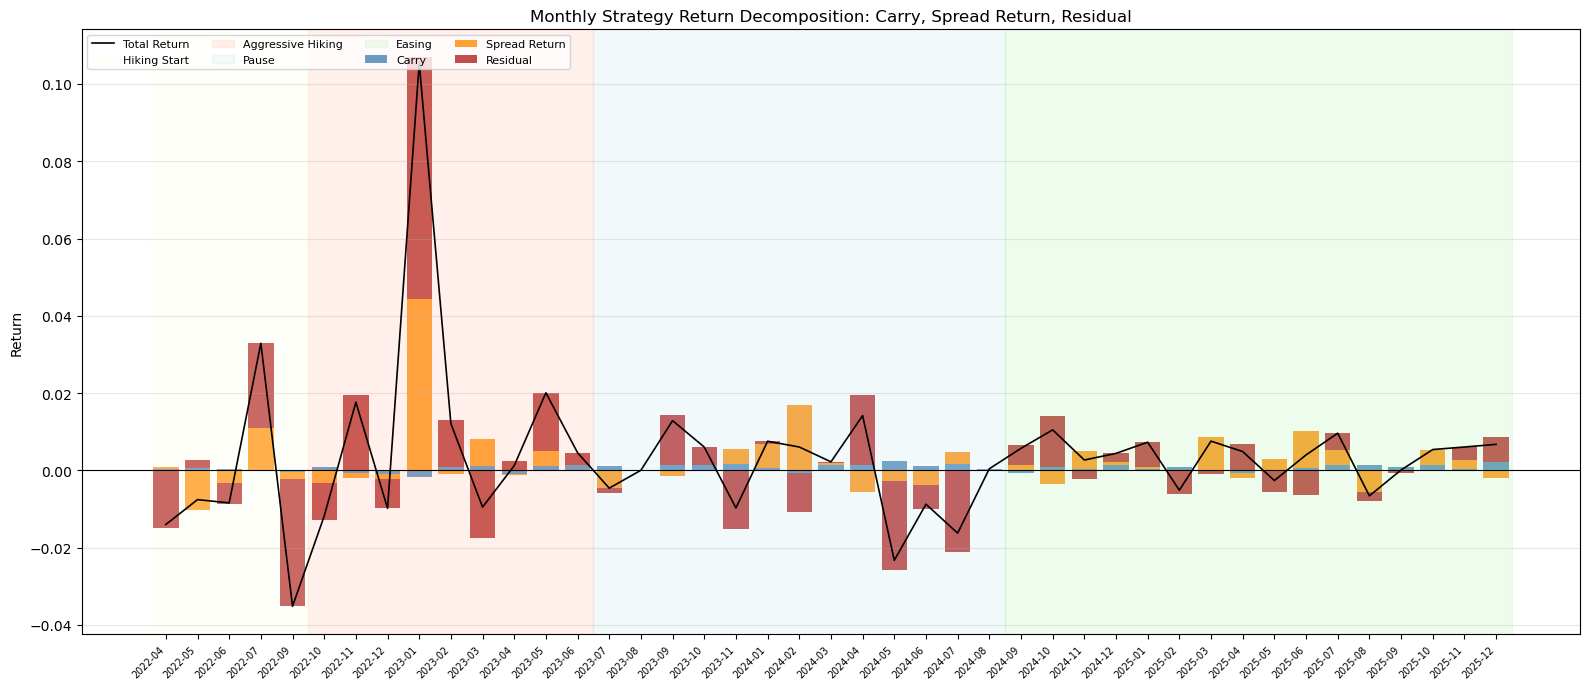

In [47]:
fig, ax = plt.subplots(figsize=(16, 7))

decomp_active = decomp[decomp['Total'].abs() > 1e-6].dropna(how='all')
x = range(len(decomp_active))

# Stacked bars — handle positive and negative separately
components = ['Carry', 'Spread Return', 'Residual']
colors = ['steelblue', 'darkorange', 'firebrick']

bottom_pos = np.zeros(len(decomp_active))
bottom_neg = np.zeros(len(decomp_active))

for comp, color in zip(components, colors):
    vals = decomp_active[comp].values
    pos_vals = np.where(vals > 0, vals, 0)
    neg_vals = np.where(vals < 0, vals, 0)
    ax.bar(x, pos_vals, bottom=bottom_pos, label=comp, color=color, alpha=0.8)
    ax.bar(x, neg_vals, bottom=bottom_neg, color=color, alpha=0.8)
    bottom_pos += pos_vals
    bottom_neg += neg_vals

# Total return line
ax.plot(x, decomp_active['Total'], 'k-', linewidth=1.2, 
        label='Total Return', zorder=5)
ax.axhline(0, color='black', linewidth=0.8)

# Regime shading
for start, end, label, color in regimes:
    mask = (decomp_active.index >= pd.Timestamp(start)) & \
           (decomp_active.index <= pd.Timestamp(end))
    if mask.any():
        indices = np.where(mask)[0]
        ax.axvspan(indices[0] - 0.5, indices[-1] + 0.5, 
                   alpha=0.15, color=color, label=label)

ax.set_xticks(range(len(decomp_active)))
ax.set_xticklabels(decomp_active.index.strftime('%Y-%m'), 
                    rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Return')
ax.set_title('Monthly Strategy Return Decomposition: Carry, Spread Return, Residual')
ax.legend(loc='upper left', fontsize=8, ncol=4)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

The residual (red) seems to be dominating the chart. This means that the strategy's P&L is driven primarily by factors outside the OAS mean-reversion signal, including option repricing, curve moves, and model error. Carry seems negligible (blue) which is expected for a long/short strategy where coupon income on the long leg is partially offset by funding costs on the short leg. Spread return (orange) is the intended driver of the strategy and does contribute meaningfully in some months like January 2023 when OAS compressed sharply as the hiking cycle neared its peak. However spread return is inconsistent, frequently near zero during stable rate periods. Overall, the chart suggest the strategy's best month was driven by option repricing and curve dynamics rather than OAS mean-reversion.


c) Compare the decomposition during two periods: (i) the pause regime (2023 H2–2024 H2) when rates were stable, and (ii) the hiking regime (2022–2023 H1) when rates moved sharply. Does the relative importance of carry vs. spread return change across regimes? Comment on what drives the residual.

In [48]:
# Q3c - Regime comparison
hiking = decomp_active.loc['2022-01-01':'2023-06-30']
pause = decomp_active.loc['2023-07-01':'2024-08-31']

# Remove zero months
hiking_active = hiking[hiking['Total'].abs() > 1e-6]
pause_active = pause[pause['Total'].abs() > 1e-6]

# Average monthly contribution
summary = pd.DataFrame({
    'Hiking (2022-2023 H1)': hiking_active.mean(),
    'Pause (2023 H2-2024 H2)': pause_active.mean()
})

print("Average monthly component contribution by regime:")
print(summary.round(4))

print(f"\nHiking active months: {len(hiking_active)}")
print(f"Pause active months: {len(pause_active)}")

# Average bonds active per regime
print(f"\nAvg bonds active per month - Hiking: {valid_counts.loc['2022-01-01':'2023-06-30'].mean():.1f}")
print(f"Avg bonds active per month - Pause: {valid_counts.loc['2023-07-01':'2024-08-31'].mean():.1f}")

Average monthly component contribution by regime:
               Hiking (2022-2023 H1)  Pause (2023 H2-2024 H2)
Carry                         0.0002                   0.0011
Spread Return                 0.0032                   0.0010
Residual                      0.0036                  -0.0031
Total                         0.0070                  -0.0010

Hiking active months: 14
Pause active months: 13

Avg bonds active per month - Hiking: 3.3
Avg bonds active per month - Pause: 4.6


Carry is small in both regimes but we see an increase during the pose which is consitent with theory that carry matters most when rates are stable and predictable. Spread return is higher during hiking than the pause which seems a bit counterintuitive as one would expect mean-reversion to work better when rates are stable. My thinking is that during the hiking cycle, OAS dislocations were larger and more frequent, giving the signal more to capture. During the pause, OAS was more stable and compressed, leaving less spread compression to exploit. The residual flips sign between regimes, positive during hiking and negative during pause. The large residual during the hiking regime could reflect the breakdown of our constant-duration approximation.As rates moved 300+ bps, a static March 2026 duration snapshot could have introduced error. During the pause, the smaller but persistently negative residual suggests the strategy was systematically losing money from sources outside OAS mean-reversion, possibly reflecting liquidity or curve-related effects that compressed bond prices despite stable OAS.

### Question 4: The Value of Modeling the Option

**Assess whether OAS-based signals outperform simpler spread signals that ignore the embedded call.**

a) Using the bonds that have both OAS and Z-spread time series, compute z-scores on the **Z-spread** (from the `z_spread` sheet) instead of OAS. Alternatively, approximate a naive spread as yield minus the interpolated swap rate (using the `ytm` sheet and `sofr_swaps.xlsx`).

In [49]:
# Q4 Setup - redefine valid bonds for comparison
# Need bonds with: OAS data + Z-spread data + duration snapshot
# Exclude FHLB 2 01/28/31 (called Dec 2022)

zsprd_bonds = zsprd.columns.tolist()
oas_bonds = oas.columns.tolist()
dur_bonds = eff_dur.dropna().index.tolist()

# Find intersection
common = [b for b in zsprd_bonds 
          if b in oas_bonds 
          and b in dur_bonds 
          and b != 'FHLB 2 01/28/31']

# Filter to bonds with enough z-spread history (< 900 NaNs)
valid_zsprd = [b for b in common if zsprd[b].isna().sum() < 900]

print(f"Valid bonds for Q4: {len(valid_zsprd)}")
print(valid_zsprd)

# Now compute z-scores
W = 60
zsprd_zscore_q4 = (zsprd[valid_zsprd] - zsprd[valid_zsprd].rolling(W).mean()) / \
                   zsprd[valid_zsprd].rolling(W).std()

oas_zscore_q4 = (oas[valid_zsprd] - oas[valid_zsprd].rolling(W).mean()) / \
                 oas[valid_zsprd].rolling(W).std()

print("\nZ-spread z-score non-NaN counts:")
print(zsprd_zscore_q4.notna().sum().sort_values(ascending=False))

print("\nOAS z-score non-NaN counts:")
print(oas_zscore_q4.notna().sum().sort_values(ascending=False))

Valid bonds for Q4: 11
['FHLB 2 09/15/31', 'FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLMC 1 12/28/28', 'FHLMC 4 09/28/29', 'FNMA 1.5 09/28/35', 'FHLB 5.5 05/15/34', 'FHLB 5.25 05/15/35', 'FHLB 5.375 12/15/34', 'FHLB 4.875 09/28/28', 'FHLB 5.125 05/15/29']

Z-spread z-score non-NaN counts:
FHLB 2 09/15/31        10
FNMA 1.5 09/28/35      10
FHLMC 1 12/28/28       10
FHLB 4.25 12/28/28      0
FHLB 4.25 03/28/30      0
FHLMC 4 09/28/29        0
FHLB 5.5 05/15/34       0
FHLB 5.25 05/15/35      0
FHLB 5.375 12/15/34     0
FHLB 4.875 09/28/28     0
FHLB 5.125 05/15/29     0
dtype: int64

OAS z-score non-NaN counts:
FHLB 2 09/15/31        984
FNMA 1.5 09/28/35      984
FHLMC 1 12/28/28       984
FHLB 4.25 12/28/28     452
FHLB 5.5 05/15/34      369
FHLB 4.875 09/28/28    366
FHLB 5.125 05/15/29    363
FHLMC 4 09/28/29       276
FHLB 5.375 12/15/34    214
FHLB 4.25 03/28/30     142
FHLB 5.25 05/15/35     118
dtype: int64


In [50]:
# How far apart are the NaNs?
nan_locs = zsprd['FHLMC 1 12/28/28'].isna()
nan_indices = np.where(nan_locs)[0]
print("NaN positions (index numbers):")
print(nan_indices)
print("\nGaps between NaNs:")
print(np.diff(nan_indices))

NaN positions (index numbers):
[  10   35   74  105  120  130  175  200  224  233  255  260  270  295
  365  380  391  435  460  493  515  520  530  555  584  625  642  653
  695  725  745  758  777  782  795  815  859  885  903  914  955  985
 1006 1018 1038]

Gaps between NaNs:
[25 39 31 15 10 45 25 24  9 22  5 10 25 70 15 11 44 25 33 22  5 10 25 29
 41 17 11 42 30 20 13 19  5 13 20 44 26 18 11 41 30 21 12 20]


In [51]:
W = 60
min_p = 50  # require at least 50 of 60 days to be non-NaN

zsprd_zscore_q4 = (zsprd[valid_zsprd] - zsprd[valid_zsprd].rolling(W, min_periods=min_p).mean()) / \
                   zsprd[valid_zsprd].rolling(W, min_periods=min_p).std()

oas_zscore_q4 = (oas[valid_zsprd] - oas[valid_zsprd].rolling(W, min_periods=min_p).mean()) / \
                 oas[valid_zsprd].rolling(W, min_periods=min_p).std()

print("Z-spread z-score non-NaN counts:")
print(zsprd_zscore_q4.notna().sum())

print("\nOAS z-score non-NaN counts:")
print(oas_zscore_q4.notna().sum())

Z-spread z-score non-NaN counts:
FHLB 2 09/15/31        949
FHLB 4.25 03/28/30     144
FHLB 4.25 12/28/28     440
FHLMC 1 12/28/28       949
FHLMC 4 09/28/29       270
FNMA 1.5 09/28/35      949
FHLB 5.5 05/15/34      359
FHLB 5.25 05/15/35     120
FHLB 5.375 12/15/34    211
FHLB 4.875 09/28/28    356
FHLB 5.125 05/15/29    353
dtype: int64

OAS z-score non-NaN counts:
FHLB 2 09/15/31        994
FHLB 4.25 03/28/30     152
FHLB 4.25 12/28/28     462
FHLMC 1 12/28/28       994
FHLMC 4 09/28/29       286
FNMA 1.5 09/28/35      994
FHLB 5.5 05/15/34      379
FHLB 5.25 05/15/35     128
FHLB 5.375 12/15/34    224
FHLB 4.875 09/28/28    376
FHLB 5.125 05/15/29    373
dtype: int64


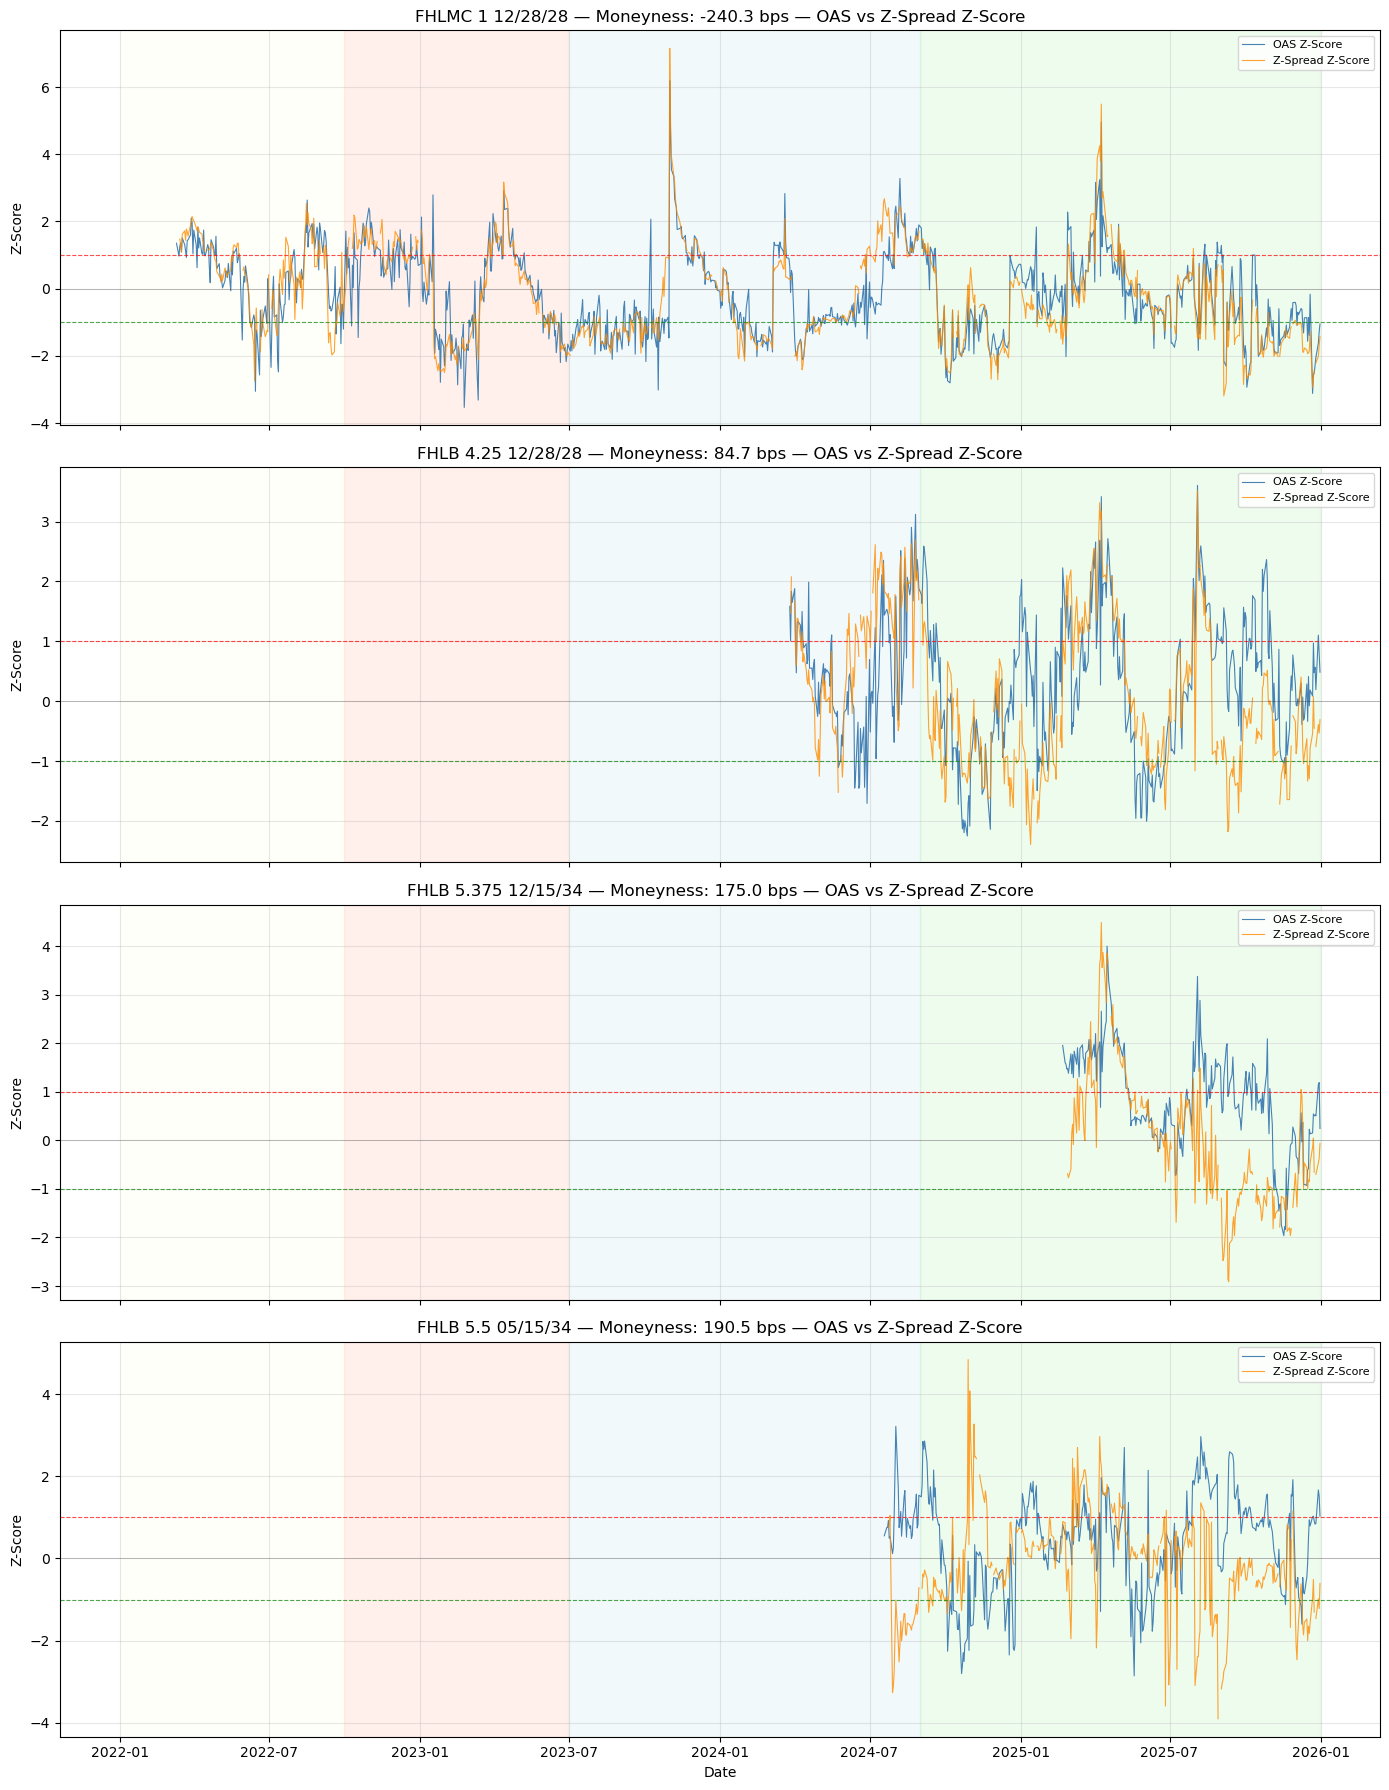

In [52]:
rep_bonds_q4 = ['FHLMC 1 12/28/28', 'FHLB 4.25 12/28/28', 
                 'FHLB 5.375 12/15/34', 'FHLB 5.5 05/15/34']

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

for ax, bond in zip(axes, rep_bonds_q4):
    ax.plot(oas_zscore_q4[bond], label='OAS Z-Score',
            color='steelblue', linewidth=0.8)
    ax.plot(zsprd_zscore_q4[bond], label='Z-Spread Z-Score',
            color='darkorange', linewidth=0.8, alpha=0.8)
    ax.axhline(1, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axhline(-1, color='green', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    
    # Get moneyness for title
    m = moneyness_df.loc[bond, 'Moneyness (bps)'] if bond in moneyness_df.index else 'N/A'
    ax.set_title(f'{bond} — Moneyness: {m} bps — OAS vs Z-Spread Z-Score')
    ax.set_ylabel('Z-Score')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    for start, end, label, color in regimes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.15, color=color)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

For deep OTM bonds, the two z-scores track almost perfectly throughout the sample. This is expected as when a bond is OTM the issuer won't exericse making the option cost low leading to Z-spread being pretty close to the OAS at all times. There is significant divergence during the easing regime for the deep ITM bonds. The Z-spread z-score spikes dramatically in mid 2024 while the OAS z-score is more contained. This reflects the option cost repricing as rates fell and the call moved deeper ITM meaning the issuer wanted to call. The Z-spread widened from option effects alone, generating a false long signal. The strategy goes long thinking the bond is cheap, when in reality the widening reflects increased option cost as the call moves deeper ITM during easing. OAS correctly strips out this option effect, avoiding the false signal.



b) Run the same long/short strategy from Q2, but using the naive spread z-score instead of OAS z-score. Compare Sharpe ratios, drawdowns, and hit rates.

In [53]:
# Q4b - Run both strategies on same 11-bond universe
# Update run_strategy_comparison to use min_periods
def run_strategy_q4(spread_data, eff_dur, bonds, window=60, threshold=1.0):
    # Rolling z-score with min_periods
    zscore = (spread_data[bonds] - spread_data[bonds].rolling(window, min_periods=50).mean()) / \
              spread_data[bonds].rolling(window, min_periods=50).std()
    
    monthly_zscore = zscore.resample('ME').last()
    
    # Signals
    signals = pd.DataFrame(0, index=monthly_zscore.index, columns=monthly_zscore.columns)
    signals[monthly_zscore > threshold] = 1
    signals[monthly_zscore < -threshold] = -1
    
    # Positions
    long_s = signals.copy()
    long_s[signals != 1] = 0
    short_s = signals.copy()
    short_s[signals != -1] = 0
    
    n_long = long_s.sum(axis=1)
    n_short = short_s.abs().sum(axis=1)
    
    long_w = long_s.div(n_long.replace(0, np.nan), axis=0).fillna(0)
    short_w = short_s.div(n_short.replace(0, np.nan), axis=0).fillna(0)
    
    # Always use OAS for returns
    monthly_oas = oas[bonds].resample('ME').last()
    delta_oas = monthly_oas.diff()
    dur = eff_dur[bonds]
    bond_ret = -dur * delta_oas / 10000
    
    long_ret = (long_w.shift(1) * bond_ret).sum(axis=1)
    short_ret = (short_w.shift(1) * bond_ret).sum(axis=1)
    strat_ret = long_ret + short_ret
    
    # Metrics
    active = strat_ret[strat_ret != 0].dropna()
    if len(active) == 0:
        return None, None
    
    ann_ret = active.mean() * 12
    ann_vol = active.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    cumulative = (1 + active).cumprod()
    rolling_max = cumulative.cummax()
    max_dd = ((cumulative - rolling_max) / rolling_max).min()
    hit_rate = (active > 0).sum() / len(active)
    
    metrics = {
        'Ann Return': ann_ret,
        'Ann Vol': ann_vol,
        'Sharpe': sharpe,
        'Max Drawdown': max_dd,
        'Hit Rate': hit_rate,
        'Active Months': len(active)
    }
    return metrics, strat_ret

# Run both
oas_metrics, oas_ret_q4 = run_strategy_q4(oas, eff_dur, valid_zsprd)
zsprd_metrics, zsprd_ret_q4 = run_strategy_q4(zsprd, eff_dur, valid_zsprd)

comparison = pd.DataFrame({
    'OAS Strategy': oas_metrics,
    'Z-Spread Strategy': zsprd_metrics
})

print(comparison.round(4))

               OAS Strategy  Z-Spread Strategy
Ann Return           0.0237            -0.0035
Ann Vol              0.0338             0.0291
Sharpe               0.6999            -0.1210
Max Drawdown        -0.0220            -0.0435
Hit Rate             0.5476             0.4390
Active Months       42.0000            41.0000


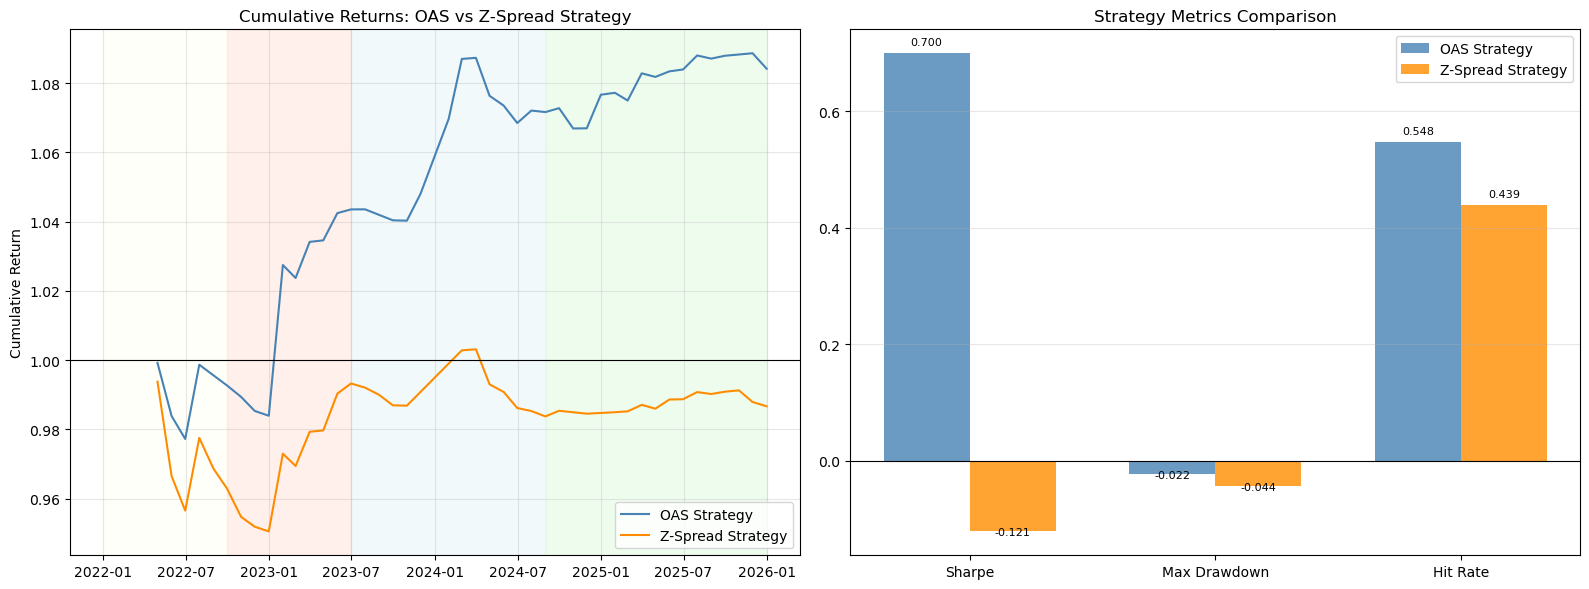

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cumulative returns
oas_active_q4 = oas_ret_q4[oas_ret_q4 != 0].dropna()
zsprd_active_q4 = zsprd_ret_q4[zsprd_ret_q4 != 0].dropna()

oas_cum_q4 = (1 + oas_active_q4).cumprod()
zsprd_cum_q4 = (1 + zsprd_active_q4).cumprod()

axes[0].plot(oas_cum_q4, color='steelblue', linewidth=1.5, label='OAS Strategy')
axes[0].plot(zsprd_cum_q4, color='darkorange', linewidth=1.5, label='Z-Spread Strategy')
axes[0].axhline(1, color='black', linewidth=0.8)
axes[0].set_title('Cumulative Returns: OAS vs Z-Spread Strategy')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
for start, end, label, color in regimes:
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.15, color=color)

# Bar chart comparison
metrics_to_plot = ['Sharpe', 'Max Drawdown', 'Hit Rate']
x = np.arange(len(metrics_to_plot))
width = 0.35

oas_vals = [oas_metrics[m] for m in metrics_to_plot]
zsprd_vals = [zsprd_metrics[m] for m in metrics_to_plot]

bars1 = axes[1].bar(x - width/2, oas_vals, width, 
                     label='OAS Strategy', color='steelblue', alpha=0.8)
bars2 = axes[1].bar(x + width/2, zsprd_vals, width,
                     label='Z-Spread Strategy', color='darkorange', alpha=0.8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_to_plot)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Strategy Metrics Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01 * np.sign(bar.get_height()),
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01 * np.sign(bar.get_height()),
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

The OAS strategy generates a Sharpe ratio of 0.70 vs -0.12 for the Z-spread strategy. The Z-spread strategy actually loses money (-0.35% annualized) while the OAS strategy earns 2.37%. The maximum drawdown is nearly double for the Z-spread strategy (-4.35% vs -2.20%), and the hit rate drops from 54.8% to 43.9% — below the 50% random baseline. The Z-spread strategy's negative performance is not random. It reflects systematic signal contamination from option cost. When implied volatility rises or rates fall (moving calls deeper ITM), option costs widen Z-spreads, generating false long signals. The strategy buys bonds that appear cheap on Z-spread but are fairly valued on OAS, then loses money as option costs normalize. The OAS strategy avoids these false signals entirely by stripping out option cost before generating the trading signal.



c) Examine how the **gap** between OAS and Z-spread z-scores varies over time. Are there episodes where the signals disagree, and which produces better subsequent P&L?

In [55]:
# Q4c - Gap between OAS and Z-spread z-scores over time
# Use bonds with full history for cleanest analysis
full_history_bonds = ['FHLB 2 09/15/31', 'FHLMC 1 12/28/28', 'FNMA 1.5 09/28/35']

# Daily gap
gap = oas_zscore_q4[full_history_bonds] - zsprd_zscore_q4[full_history_bonds]
gap_mean = gap.mean(axis=1)

# Monthly gap at rebalancing dates
monthly_oas_zscore = oas_zscore_q4.resample('ME').last()
monthly_zsprd_zscore = zsprd_zscore_q4.resample('ME').last()
monthly_gap = (monthly_oas_zscore - monthly_zsprd_zscore)[full_history_bonds].mean(axis=1)

# Find episodes where signals disagree
# Disagree = one is above threshold, other is below
threshold = 1.0
oas_signal = monthly_oas_zscore[valid_zsprd].apply(
    lambda x: np.where(x > threshold, 1, np.where(x < -threshold, -1, 0)))
zsprd_signal = monthly_zsprd_zscore[valid_zsprd].apply(
    lambda x: np.where(x > threshold, 1, np.where(x < -threshold, -1, 0)))

# Disagreement = signals have opposite signs
disagreement = (oas_signal * zsprd_signal < 0).sum(axis=1)

print("Months with signal disagreement:")
print(disagreement[disagreement > 0])
print(f"\nTotal disagreement months: {(disagreement > 0).sum()}")
print(f"Total active months: {(disagreement >= 0).sum()}")

Months with signal disagreement:
date
2024-06-30    2
2024-07-31    2
2024-10-31    1
2025-07-31    1
2025-08-31    1
dtype: int64

Total disagreement months: 5
Total active months: 48


The fact that there are only 5 disagreement months makes sense since most of the bonds are OTM where the signals track closely. The disagreements are concentrated in the easing regime (2024-2025) as expected from the z-score plots.

In [56]:
# Compare subsequent P&L for agreement vs disagreement months
# Use the strategy returns we already computed

# Align disagreement indicator with returns
disagreement_bool = disagreement > 0

# OAS strategy returns
oas_ret_monthly = oas_ret_q4.reindex(disagreement.index)
zsprd_ret_monthly = zsprd_ret_q4.reindex(disagreement.index)

# Split into agreement and disagreement months
agree_oas = oas_ret_monthly[~disagreement_bool]
disagree_oas = oas_ret_monthly[disagreement_bool]

agree_zsprd = zsprd_ret_monthly[~disagreement_bool]
disagree_zsprd = zsprd_ret_monthly[disagreement_bool]

print("OAS Strategy:")
print(f"  Agreement months avg return:    {agree_oas.mean():.4f}")
print(f"  Disagreement months avg return: {disagree_oas.mean():.4f}")

print("\nZ-Spread Strategy:")
print(f"  Agreement months avg return:    {agree_zsprd.mean():.4f}")
print(f"  Disagreement months avg return: {disagree_zsprd.mean():.4f}")

print("\nDisagreement months detail:")
print(pd.DataFrame({
    'OAS Return': oas_ret_monthly[disagreement_bool],
    'Z-Spread Return': zsprd_ret_monthly[disagreement_bool],
    'Disagreements': disagreement[disagreement_bool]
}).round(4))

OAS Strategy:
  Agreement months avg return:    0.0020
  Disagreement months avg return: -0.0008

Z-Spread Strategy:
  Agreement months avg return:    -0.0002
  Disagreement months avg return: -0.0008

Disagreement months detail:
            OAS Return  Z-Spread Return  Disagreements
date                                                  
2024-06-30     -0.0047          -0.0047              2
2024-07-31      0.0034          -0.0009              2
2024-10-31     -0.0055           0.0000              1
2025-07-31      0.0037           0.0021              1
2025-08-31     -0.0008          -0.0006              1


`OAS produces better subsequent P&L in both cases. `

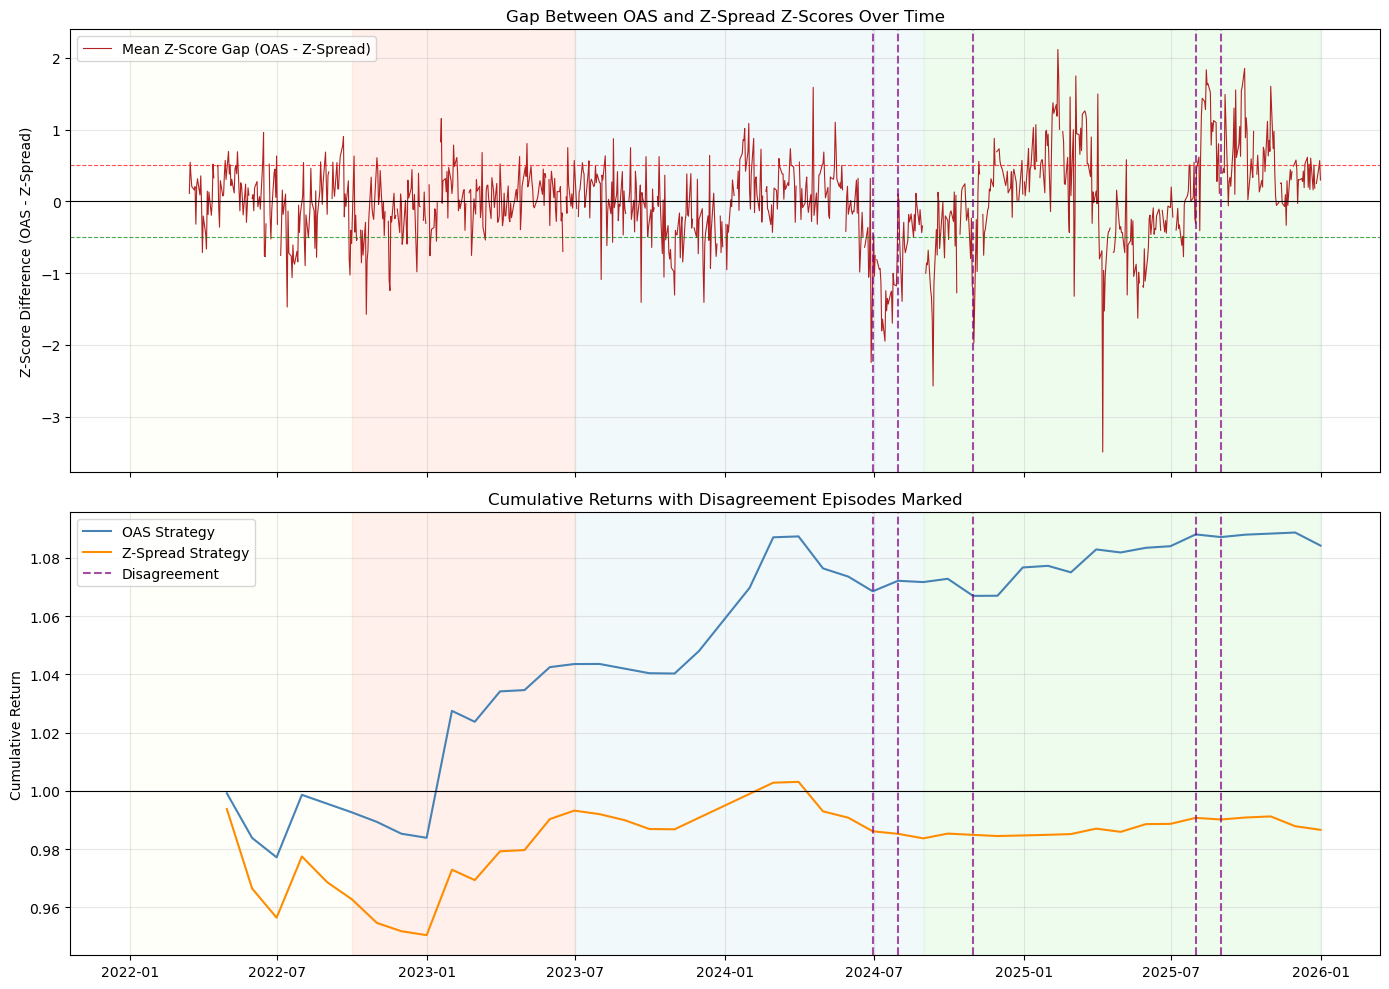

In [57]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot 1: Daily gap over time
axes[0].plot(gap_mean, color='firebrick', linewidth=0.8, 
             label='Mean Z-Score Gap (OAS - Z-Spread)')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].axhline(-0.5, color='green', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].set_title('Gap Between OAS and Z-Spread Z-Scores Over Time')
axes[0].set_ylabel('Z-Score Difference (OAS - Z-Spread)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for start, end, label, color in regimes:
    axes[0].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.15, color=color)

# Mark disagreement months
for date in disagreement[disagreement > 0].index:
    axes[0].axvline(date, color='purple', linewidth=1.5, 
                    alpha=0.7, linestyle='--')

# Plot 2: OAS vs Z-spread cumulative returns with disagreement marked
axes[1].plot(oas_cum_q4, color='steelblue', linewidth=1.5, label='OAS Strategy')
axes[1].plot(zsprd_cum_q4, color='darkorange', linewidth=1.5, label='Z-Spread Strategy')
axes[1].axhline(1, color='black', linewidth=0.8)

for date in disagreement[disagreement > 0].index:
    axes[1].axvline(date, color='purple', linewidth=1.5,
                    alpha=0.7, linestyle='--', label='Disagreement' 
                    if date == disagreement[disagreement > 0].index[0] else '')

axes[1].set_title('Cumulative Returns with Disagreement Episodes Marked')
axes[1].set_ylabel('Cumulative Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for start, end, label, color in regimes:
    axes[1].axvspan(pd.Timestamp(start), pd.Timestamp(end),
                    alpha=0.15, color=color)

plt.tight_layout()
plt.show()

The OAS signal outperforms in agreement months by a wide margin (+0.20% vs -0.02%), and neither signal clearly wins during the rare disagreement episodes. This confirms that the value of OAS modeling comes primarily from avoiding false signals in normal conditions, not from superior performance during extreme disagreement episodes.

d) Summarize: how much value comes from correctly modeling the embedded option?


Correctly modeling the embedded option is the difference between a profitable and a loss-making strategy.
The OAS strategy earns a Sharpe of 0.70 vs -0.12 for Z-spread — a gap of 272 bps in annualized return. The Z-spread signal is contaminated by option cost fluctuations, causing the strategy to trade on noise rather than genuine spread cheapness, with a hit rate below 50% (43.9%). The value of OAS modeling is largest for ITM bonds during rate transitions — when option costs reprice most rapidly — and negligible for OTM bonds where option cost is small and stable. In stable rate environments the two strategies perform similarly, confirming that option modeling matters most precisely when rates are moving and the cost of ignoring the embedded call is highest.

### Question 5: Regime Analysis

**Analyze how option cost and strategy performance vary across rate regimes.**

Use the following regime definitions:

| Regime | Start | End | Description |
|--------|-------|-----|-------------|
| Hiking Start | 2022-01-01 | 2022-09-30 | Fed Funds from 0.25% to ~3.25% |
| Aggressive Hiking | 2022-10-01 | 2023-06-30 | Fed Funds from ~3.25% to 5.25% |
| Pause | 2023-07-01 | 2024-08-31 | Holding at 5.25–5.50% |
| Easing | 2024-09-01 | 2025-12-31 | First cuts begin |

a) For each regime, compute the **average option cost** for bonds in each moneyness group (deep OTM, near ATM, deep ITM from Q1). How does option cost evolve as the rate cycle progresses?

In [58]:
# Q5a - Average option cost by regime and moneyness group
# Option cost time series = zsprd - oas (daily)
opt_cost_ts = zsprd[valid_zsprd] - oas[valid_zsprd]

# Assign moneyness groups from Q1 cutoffs (±100 bps)
moneyness_q1 = moneyness_df['Moneyness (bps)']

deep_otm = [b for b in valid_zsprd if b in moneyness_q1.index and moneyness_q1[b] < -100]
near_atm  = [b for b in valid_zsprd if b in moneyness_q1.index and -100 <= moneyness_q1[b] <= 100]
deep_itm  = [b for b in valid_zsprd if b in moneyness_q1.index and moneyness_q1[b] > 100]

print("Deep OTM bonds:", deep_otm)
print("Near ATM bonds:", near_atm)
print("Deep ITM bonds:", deep_itm)

# Regime dates
regimes_q5 = [
    ('2022-01-01', '2022-09-30', 'Hiking Start'),
    ('2022-10-01', '2023-06-30', 'Aggressive Hiking'),
    ('2023-07-01', '2024-08-31', 'Pause'),
    ('2024-09-01', '2025-12-31', 'Easing'),
]

# Average option cost per regime per group
results = {}
for start, end, label in regimes_q5:
    mask = (opt_cost_ts.index >= start) & (opt_cost_ts.index <= end)
    period = opt_cost_ts.loc[mask]
    results[label] = {
        'Deep OTM':  period[deep_otm].mean().mean()  if deep_otm  else np.nan,
        'Near ATM':  period[near_atm].mean().mean()  if near_atm  else np.nan,
        'Deep ITM':  period[deep_itm].mean().mean()  if deep_itm  else np.nan,
    }

q5a = pd.DataFrame(results).T
print("\nAverage Option Cost (bps) by Regime and Moneyness Group:")
print(q5a.round(2))

Deep OTM bonds: ['FHLB 2 09/15/31', 'FHLMC 1 12/28/28', 'FNMA 1.5 09/28/35']
Near ATM bonds: ['FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLMC 4 09/28/29']
Deep ITM bonds: ['FHLB 5.5 05/15/34', 'FHLB 5.25 05/15/35', 'FHLB 5.375 12/15/34', 'FHLB 4.875 09/28/28', 'FHLB 5.125 05/15/29']

Average Option Cost (bps) by Regime and Moneyness Group:
                   Deep OTM  Near ATM  Deep ITM
Hiking Start          31.40       NaN       NaN
Aggressive Hiking     30.36       NaN       NaN
Pause                 32.46     48.22     94.31
Easing                39.22     50.35     86.61


In [59]:
# only showing bonds available in each regime
results_v2 = {}
for start, end, label in regimes_q5:
    mask = (opt_cost_ts.index >= start) & (opt_cost_ts.index <= end)
    period = opt_cost_ts.loc[mask]
    results_v2[label] = {
        'Deep OTM': period[deep_otm].mean().mean() if deep_otm else np.nan,
        'Near ATM': period[[b for b in near_atm if period[b].notna().sum() > 20]].mean().mean() if near_atm else np.nan,
        'Deep ITM': period[[b for b in deep_itm if period[b].notna().sum() > 20]].mean().mean() if deep_itm else np.nan,
    }

q5a_v2 = pd.DataFrame(results_v2).T
print("Average Option Cost (bps) — bonds with >20 obs only:")
print(q5a_v2.round(2))

Average Option Cost (bps) — bonds with >20 obs only:
                   Deep OTM  Near ATM  Deep ITM
Hiking Start          31.40       NaN       NaN
Aggressive Hiking     30.36       NaN       NaN
Pause                 32.46     48.22     94.31
Easing                39.22     50.35     86.61


Near ATM and Deep ITM bonds are unavailable during the hiking regimes, these high-coupon bonds (4.25-5.5%) were issued in 2023-2024 when rates were elevated and do not appear in the panel until the pause regime. The analysis is therefore limited to deep OTM bonds across all four regimes, with near ATM and deep ITM comparisons only available from the pause onward.

Deep OTM option cost is stable across all regimes (30-39 bps), confirming that deeply OTM calls have little value regardless of the rate environment and time value dominates. The slight uptick during easing (39 bps) reflects modest vol repricing as uncertainty about the cutting cycle increased.
For near ATM and deep ITM bonds, only pause and easing regimes are available since these high-coupon bonds were issued in 2023-2024. Near ATM option cost is stable (48→50 bps) as rates fell slightly. Deep ITM option cost declines (94→87 bps) as bonds approached near-certain call exercise, compressing the option premium as uncertainty resolves.


b) Compute the **Sharpe ratio of the Q2 strategy** in each regime separately. Explain the variation across regimes.


In [60]:
# Q5b - Sharpe ratio of Q2 strategy by regime
# Use the full Q2 strategy returns (16 bonds, 60-day window, threshold=1.0)

print("Strategy returns sample:")
print(strategy_ret.head())
print(f"\nDate range: {strategy_ret.index[0]} to {strategy_ret.index[-1]}")

# Compute Sharpe per regime
def regime_sharpe(returns, start, end, label):
    mask = (returns.index >= start) & (returns.index <= end)
    r = returns.loc[mask]
    active = r[r != 0].dropna()
    if len(active) < 3:
        return {'Regime': label, 'Sharpe': np.nan, 
                'Ann Return': np.nan, 'Ann Vol': np.nan,
                'Hit Rate': np.nan, 'Active Months': len(active)}
    ann_ret = active.mean() * 12
    ann_vol = active.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    hit_rate = (active > 0).sum() / len(active)
    return {'Regime': label, 'Sharpe': sharpe,
            'Ann Return': ann_ret, 'Ann Vol': ann_vol,
            'Hit Rate': hit_rate, 'Active Months': len(active)}

results_q5b = []
for start, end, label in regimes_q5:
    results_q5b.append(regime_sharpe(strategy_ret, start, end, label))

q5b = pd.DataFrame(results_q5b).set_index('Regime')
print("\nQ2 Strategy Performance by Regime:")
print(q5b.round(4))

Strategy returns sample:
date
2022-01-31    0.000000
2022-02-28    0.000000
2022-03-31    0.000000
2022-04-30    0.000585
2022-05-31   -0.010938
Freq: ME, dtype: float64

Date range: 2022-01-31 00:00:00 to 2025-12-31 00:00:00

Q2 Strategy Performance by Regime:
                   Sharpe  Ann Return  Ann Vol  Hit Rate  Active Months
Regime                                                                 
Hiking Start      -0.6605     -0.0196   0.0296    0.3333              6
Aggressive Hiking  1.3447      0.0700   0.0521    0.4444              9
Pause              0.6423      0.0126   0.0197    0.5385             13
Easing             1.3270      0.0191   0.0144    0.7500             16


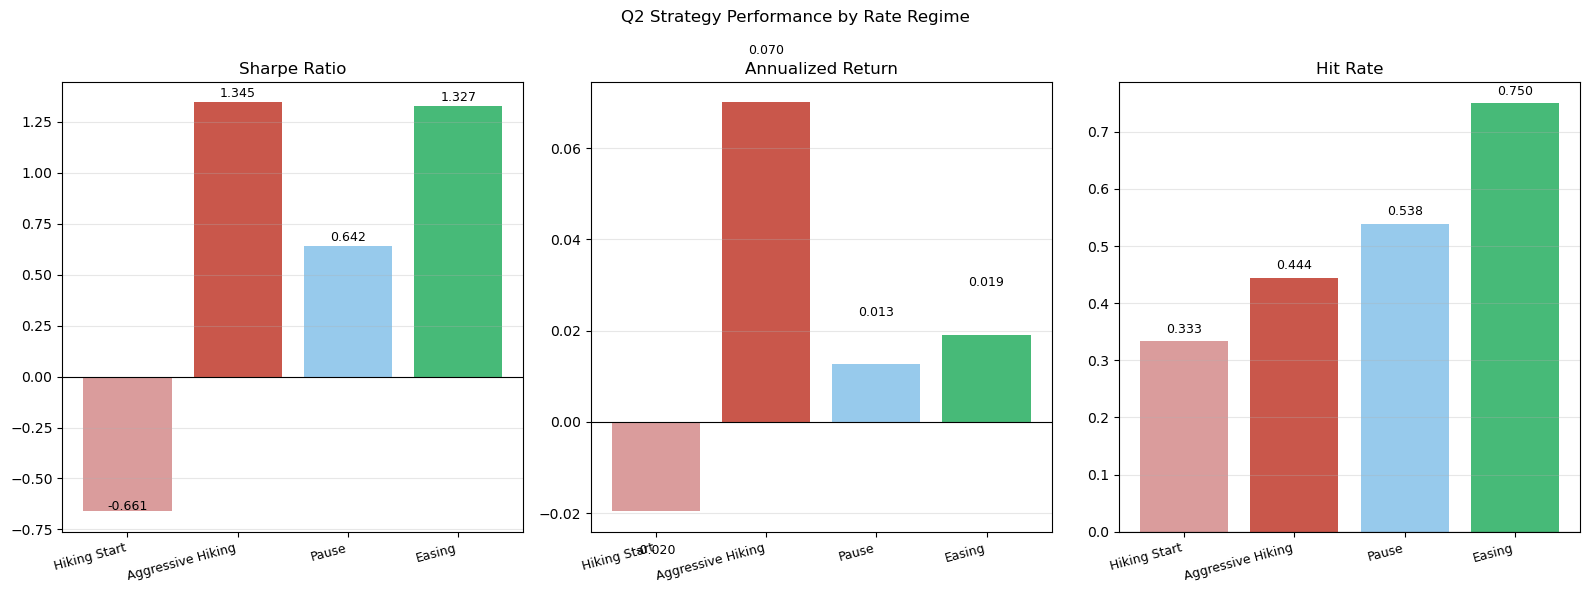

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

regime_labels = q5b.index.tolist()
x = np.arange(len(regime_labels))
colors = ['#d48b8b', '#c0392b', '#85c1e9', '#27ae60']  # hiking start, agg hiking, pause, easing

for ax, metric, title in zip(axes, 
                               ['Sharpe', 'Ann Return', 'Hit Rate'],
                               ['Sharpe Ratio', 'Annualized Return', 'Hit Rate']):
    bars = ax.bar(x, q5b[metric], color=colors, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(regime_labels, rotation=15, ha='right', fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, q5b[metric]):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    val + 0.01 * np.sign(val),
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Q2 Strategy Performance by Rate Regime', fontsize=12)
plt.tight_layout()
plt.show()

In [62]:
# How much does Jan 2023 affect aggressive hiking Sharpe?
mask = (strategy_ret.index >= '2022-10-01') & (strategy_ret.index <= '2023-06-30')
agg_hiking = strategy_ret.loc[mask]
agg_hiking_active = agg_hiking[agg_hiking != 0].dropna()

# With and without Jan 2023
with_jan = agg_hiking_active
without_jan = agg_hiking_active.drop(pd.Timestamp('2023-01-31'), errors='ignore')

for label, r in [('With Jan 2023', with_jan), ('Without Jan 2023', without_jan)]:
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    print(f"{label}: Sharpe={ann_ret/ann_vol:.2f}, Ann Return={ann_ret:.2%}")

With Jan 2023: Sharpe=1.34, Ann Return=7.00%
Without Jan 2023: Sharpe=0.78, Ann Return=1.24%


The aggressive hiking regime appears to be the best performing with a Sharpe of 1.34 and 7.0% annualized return. However this is heavily distorted by the January 2023 outlier (+10.5% in a single month). Excluding it, the Sharpe drops to 0.78 and annualized return to 1.24% — more in line with the pause regime. With only 9 active months, a single observation accounts for the majority of the regime's apparent outperformance. The aggressive hiking result should therefore be interpreted cautiously. Stripping out the January 2023 outlier, the true performance ranking is: Easing (1.33) > Pause (0.64) ≈ Aggressive Hiking (0.78) > Hiking Start (-0.66). The monotonically improving hit rate across regimes (33% → 44% → 54% → 75%) is the more reliable indicator of strategy quality — it is not distorted by outliers and confirms that the signal becomes progressively more reliable as the rate cycle matures and OAS mean-reversion becomes more predictable.


c) During the hiking regime, many previously high-coupon callable bonds saw their calls go from ITM to OTM as rates rose above their coupon. Pick one or two specific bonds and trace their OAS and option cost through the hiking period.

In [63]:
# Q5c - Trace OAS and option cost through hiking for specific bonds
# Need bonds that were ITM at start of hiking but went OTM as rates rose
# Best candidates: bonds with coupons around 2-4% that started near ATM

# Check which bonds have both OAS and zsprd during hiking
hiking_mask = (oas.index >= '2022-01-01') & (oas.index <= '2023-06-30')

print("OAS coverage during hiking:")
print(oas.loc[hiking_mask].notna().sum().sort_values(ascending=False))

print("\nZ-spread coverage during hiking:")
print(zsprd.loc[hiking_mask].notna().sum().sort_values(ascending=False))

OAS coverage during hiking:
FHLB 2 01/28/31        390
FHLB 2 09/15/31        390
FNMA 1.5 09/28/35      390
FHLMC 1.5 01/28/33     390
FHLMC 1 12/28/28       390
FNMA 1 09/28/29        390
FHLB 5 09/28/32        213
FHLMC 4.75 01/28/28    114
FHLB 4.25 12/28/28       0
FHLB 5.25 03/28/29       0
FHLB 5 12/15/27          0
FHLB 5 01/15/30          0
FHLB 4.75 06/15/28       0
FHLB 4.25 03/28/30       0
FHLMC 4 09/28/29         0
FHLMC 3.75 06/28/30      0
FHLB 5.5 12/28/28        0
FHLMC 5.5 09/28/28       0
FHLMC 5.25 01/28/30      0
FNMA 5 03/15/30          0
FHLB 5.5 05/15/34        0
FHLB 5.25 05/15/35       0
FHLB 5.375 12/15/34      0
FHLB 4.875 09/28/28      0
FHLB 5.125 05/15/29      0
dtype: int64

Z-spread coverage during hiking:
FHLB 2 09/15/31        374
FHLMC 1 12/28/28       374
FNMA 1.5 09/28/35      374
FHLB 2 01/28/31         60
FHLB 5 09/28/32         26
FHLB 4.25 12/28/28       0
FHLB 4.25 03/28/30       0
FHLMC 1.5 01/28/33       0
FHLMC 3.75 06/28/30      0
FHLMC 4

Best candidates: 
- FHLMC 1 12/28/28 (1% coupon) — full OAS and Z-spread coverage
- FHLB 2 09/15/31 (2% coupon) — full OAS and Z-spread coverage

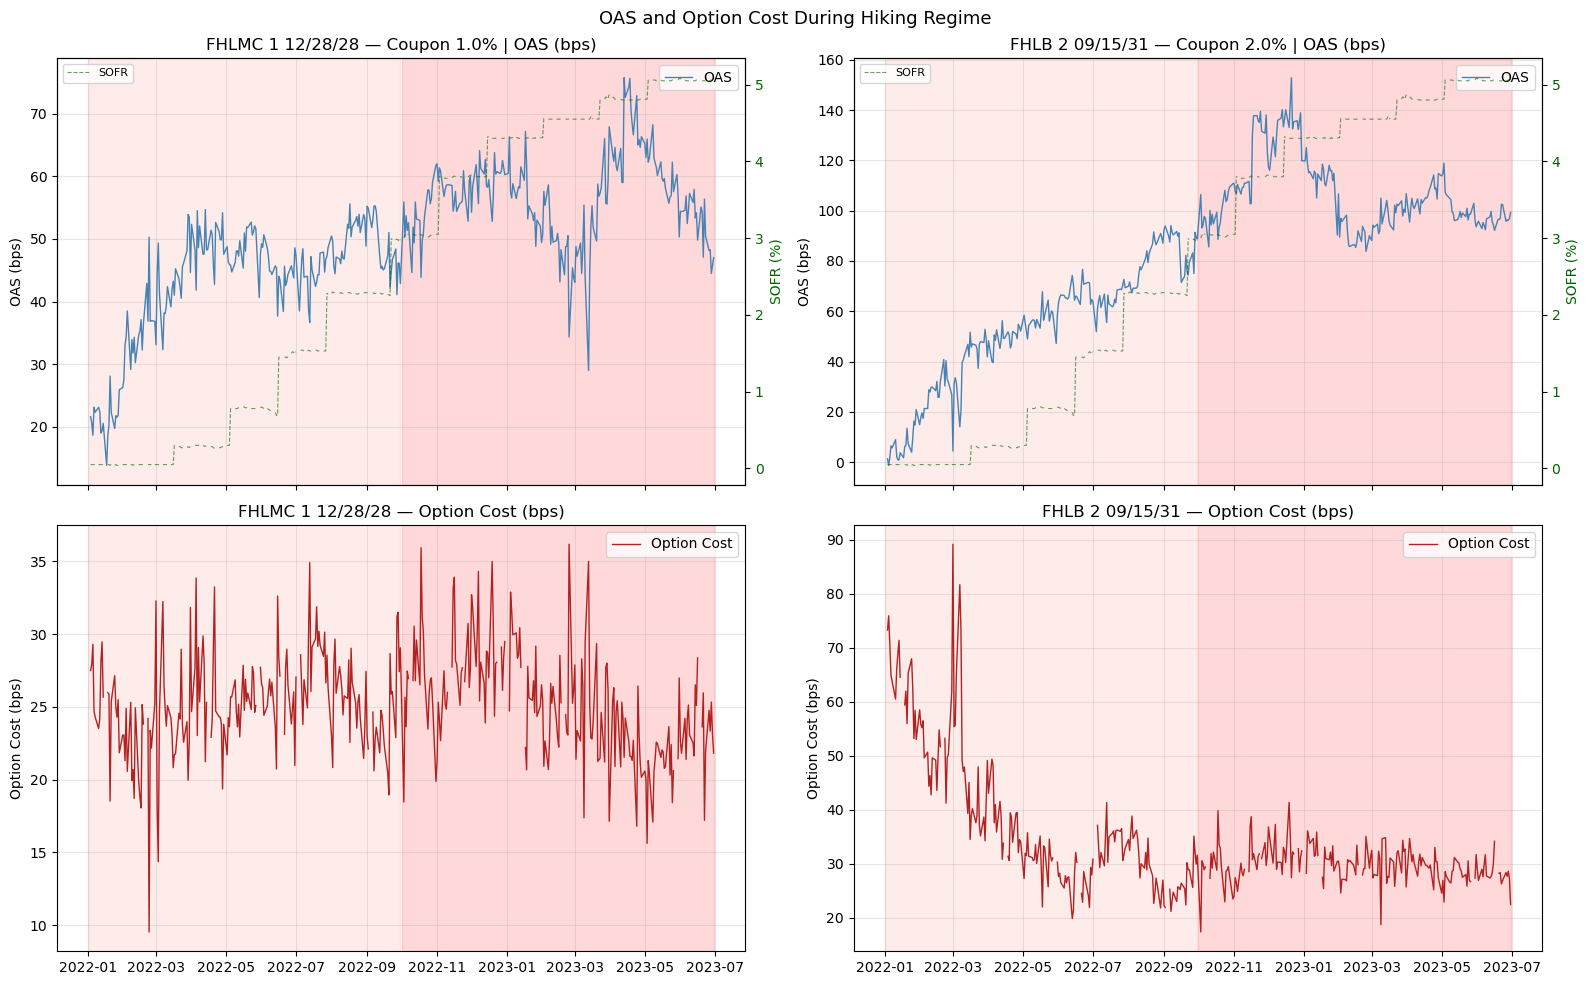

In [64]:
# Q5c - Trace OAS and option cost through hiking
bonds_q5c = ['FHLMC 1 12/28/28', 'FHLB 2 09/15/31']

opt_cost_q5c = zsprd[bonds_q5c] - oas[bonds_q5c]

# Use date slicing instead of boolean mask
start_hike = '2022-01-01'
end_hike = '2023-06-30'

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for col, bond in enumerate(bonds_q5c):
    cpn = float(info.loc['Cpn Rate', bond]) * 100

    # OAS
    axes[0, col].plot(oas.loc[start_hike:end_hike, bond],
                      color='steelblue', linewidth=1.0, label='OAS')
    axes[0, col].set_title(f'{bond} — Coupon {cpn:.1f}% | OAS (bps)')
    axes[0, col].set_ylabel('OAS (bps)')
    axes[0, col].grid(True, alpha=0.3)

    # Option Cost
    axes[1, col].plot(opt_cost_q5c.loc[start_hike:end_hike, bond],
                      color='firebrick', linewidth=1.0, label='Option Cost')
    axes[1, col].set_title(f'{bond} — Option Cost (bps)')
    axes[1, col].set_ylabel('Option Cost (bps)')
    axes[1, col].grid(True, alpha=0.3)

    # Regime shading
    for ax in [axes[0, col], axes[1, col]]:
        ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-09-30'),
                   alpha=0.15, color='salmon')
        ax.axvspan(pd.Timestamp('2022-10-01'), pd.Timestamp('2023-06-30'),
                   alpha=0.15, color='red')
        ax.grid(True, alpha=0.3)

    # SOFR on secondary axis
    ax2 = axes[0, col].twinx()
    ax2.plot(rates['SOFR'].loc[start_hike:end_hike], color='darkgreen',
             linewidth=0.8, linestyle='--', alpha=0.6, label='SOFR')
    ax2.set_ylabel('SOFR (%)', color='darkgreen')
    ax2.tick_params(axis='y', labelcolor='darkgreen')
    ax2.legend(loc='upper left', fontsize=8)

axes[0, 0].legend(loc='upper right')
axes[1, 0].legend(loc='upper right')
axes[0, 1].legend(loc='upper right')
axes[1, 1].legend(loc='upper right')

plt.suptitle('OAS and Option Cost During Hiking Regime', fontsize=13)
plt.tight_layout()
plt.show()

FHLMC 1 12/28/28 (1% coupon): OAS widened from ~20 to ~75 bps as the bond moved deeply OTM — the market demanding compensation for holding a well-below-market coupon. Option cost remained stable throughout (20-35 bps), reflecting pure time value with no intrinsic value to lose since the 1% coupon was already near OTM at the start of hiking.

FHLB 2 09/15/31 (2% coupon): A more dramatic transition. OAS widened from near 0 to ~150 bps. Option cost tells the clearest story — collapsing from ~75-85 bps in early 2022 to ~25-30 bps by mid-2022 as SOFR crossed the 2% coupon threshold. This is the ITM→OTM transition in real time: the call's intrinsic value was destroyed as rates rose, leaving only residual time value. The speed of the collapse mirrors the pace of Fed hikes.

Overall, it seems option cost is a direct barometer of where the call sits relative to current rates. For FHLB 2, the 50+ bps drop in option cost over six months represents real economic value transferred from bondholder to issuer as the embedded call moved OTM.


d) Based on your analysis, when should a portfolio manager use or avoid this strategy?


I would advise a portfolio manager to use this strategy when a rate regime seems established and stable. The strategy performs best during the pause (Sharpe 0.64) and easing (Sharpe 1.33) when OAS mean-reversion is predictable and the rolling z-score has a reliable historical anchor. The monotonically improving hit rate (33% → 75%) across regimes confirms the signal strengthens as volatility subsides. The universe contains near-ATM callable bonds. These offer the best risk/reward — meaningful OAS signal, non-trivial duration, and stable enough option cost to make the z-score informative. I would say to avoid the strategy when rate regime is transitioning abruptly. The hiking start regime (Sharpe -0.66) shows the strategy breaks down when rates are moving faster than the 60-day rolling window can adapt. Historical z-scores become poor anchors when the rate level itself is shifting structurally. The universe is dominated by deeply ITM bonds. Option cost is large, volatile, and difficult to model accurately — residual risk dominates spread return as shown in Q3.


e) Propose one modification to the Q2 strategy that might improve performance. Describe the logic, implement a simple version, and compare its Sharpe ratio to the baseline.


We are going to test
1. Regime filter: Only trade when the rate environment is stable (e.g. realized vol of SOFR below a threshold). Avoids the hiking start blowup.
2. Volatility-adjusted threshold: Scale the z-score threshold by implied vol, require a higher z-score to trade when vol is elevated, reducing false signals during volatile periods.
3. Moneyness filter: Only trade near-ATM bonds (±100 bps moneyness) where the OAS signal is most informative and option cost is meaningful but not dominant.

In [65]:
# Q5e - Three strategy modifications

# Baseline: Q2 strategy (60-day window, threshold=1.0, 16 bonds)
# Already computed as strat_ret

# --------------------------------------------------
# Modification 1: Regime Filter
# Only trade when SOFR 30-day realized vol is below threshold
# --------------------------------------------------
sofr_daily = rates['SOFR'].ffill()
sofr_vol = sofr_daily.rolling(30).std()
sofr_vol_monthly = sofr_vol.resample('ME').last()

# Threshold: median SOFR vol
vol_threshold = sofr_vol_monthly.median()
print(f"SOFR vol threshold (median): {vol_threshold:.4f}")

# Recompute Q2 signals
W = 60
oas_zscore_q2 = (oas[usable_bonds] - oas[usable_bonds].rolling(W).mean()) / \
                 oas[usable_bonds].rolling(W).std()
monthly_zscore_q2 = oas_zscore_q2.resample('ME').last()

signals_base = pd.DataFrame(0, index=monthly_zscore_q2.index, columns=monthly_zscore_q2.columns)
signals_base[monthly_zscore_q2 > 1] = 1
signals_base[monthly_zscore_q2 < -1] = -1

long_s = signals_base.copy(); long_s[signals_base != 1] = 0
short_s = signals_base.copy(); short_s[signals_base != -1] = 0
n_long = long_s.sum(axis=1); n_short = short_s.abs().sum(axis=1)
long_w = long_s.div(n_long.replace(0, np.nan), axis=0).fillna(0)
short_w = short_s.div(n_short.replace(0, np.nan), axis=0).fillna(0)

monthly_oas_q2 = oas[usable_bonds].resample('ME').last()
delta_oas_q2 = monthly_oas_q2.diff()
bond_ret_q2 = -eff_dur[usable_bonds] * delta_oas_q2 / 10000

# Regime filter — zero out positions in high vol months
regime_mask = sofr_vol_monthly.reindex(monthly_zscore_q2.index) < vol_threshold
long_w_rf = long_w.multiply(regime_mask.astype(int), axis=0)
short_w_rf = short_w.multiply(regime_mask.astype(int), axis=0)

strat_rf = (long_w_rf.shift(1) * bond_ret_q2).sum(axis=1) + \
           (short_w_rf.shift(1) * bond_ret_q2).sum(axis=1)

# --------------------------------------------------
# Modification 2: Moneyness Filter
# Only trade near-ATM bonds (±100 bps)
# --------------------------------------------------
near_atm_all = [b for b in usable_bonds 
                if b in moneyness_q1.index 
                and -100 <= moneyness_q1[b] <= 100]
print(f"\nNear ATM bonds available: {near_atm_all}")

if len(near_atm_all) > 0:
    monthly_zscore_atm = monthly_zscore_q2[near_atm_all]
    signals_atm = pd.DataFrame(0, index=monthly_zscore_atm.index, 
                                columns=monthly_zscore_atm.columns)
    signals_atm[monthly_zscore_atm > 1] = 1
    signals_atm[monthly_zscore_atm < -1] = -1

    long_atm = signals_atm.copy(); long_atm[signals_atm != 1] = 0
    short_atm = signals_atm.copy(); short_atm[signals_atm != -1] = 0
    n_long_atm = long_atm.sum(axis=1); n_short_atm = short_atm.abs().sum(axis=1)
    long_w_atm = long_atm.div(n_long_atm.replace(0, np.nan), axis=0).fillna(0)
    short_w_atm = short_atm.div(n_short_atm.replace(0, np.nan), axis=0).fillna(0)

    strat_atm = (long_w_atm.shift(1) * bond_ret_q2[near_atm_all]).sum(axis=1) + \
                (short_w_atm.shift(1) * bond_ret_q2[near_atm_all]).sum(axis=1)
else:
    print("No near ATM bonds with duration — moneyness filter not viable")
    strat_atm = None

# --------------------------------------------------
# Modification 3: Vol-Adjusted Threshold
# Higher threshold when SOFR vol is high
# --------------------------------------------------
# Scale threshold between 1.0 (low vol) and 2.0 (high vol)
vol_normalized = (sofr_vol_monthly - sofr_vol_monthly.min()) / \
                 (sofr_vol_monthly.max() - sofr_vol_monthly.min())
dynamic_threshold = 1.0 + vol_normalized  # ranges from 1.0 to 2.0

signals_vt = pd.DataFrame(0, index=monthly_zscore_q2.index, 
                           columns=monthly_zscore_q2.columns)
for date in monthly_zscore_q2.index:
    if date in dynamic_threshold.index:
        thresh = dynamic_threshold.loc[date]
        if not np.isnan(thresh):
            signals_vt.loc[date, monthly_zscore_q2.loc[date] > thresh] = 1
            signals_vt.loc[date, monthly_zscore_q2.loc[date] < -thresh] = -1

long_vt = signals_vt.copy(); long_vt[signals_vt != 1] = 0
short_vt = signals_vt.copy(); short_vt[signals_vt != -1] = 0
n_long_vt = long_vt.sum(axis=1); n_short_vt = short_vt.abs().sum(axis=1)
long_w_vt = long_vt.div(n_long_vt.replace(0, np.nan), axis=0).fillna(0)
short_w_vt = short_vt.div(n_short_vt.replace(0, np.nan), axis=0).fillna(0)

strat_vt = (long_w_vt.shift(1) * bond_ret_q2).sum(axis=1) + \
           (short_w_vt.shift(1) * bond_ret_q2).sum(axis=1)

# --------------------------------------------------
# Compare all strategies
# --------------------------------------------------
def compute_metrics(ret, label):
    active = ret[ret != 0].dropna()
    if len(active) < 3:
        return None
    ann_ret = active.mean() * 12
    ann_vol = active.std() * np.sqrt(12)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    cumulative = (1 + active).cumprod()
    max_dd = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()
    hit_rate = (active > 0).sum() / len(active)
    return {'Strategy': label, 'Ann Return': ann_ret, 'Ann Vol': ann_vol,
            'Sharpe': sharpe, 'Max Drawdown': max_dd, 
            'Hit Rate': hit_rate, 'Active Months': len(active)}

results_q5e = [
    compute_metrics(strategy_ret, 'Baseline'),
    compute_metrics(strat_rf, 'Regime Filter'),
    compute_metrics(strat_vt, 'Vol-Adjusted Threshold'),
]
if strat_atm is not None:
    results_q5e.append(compute_metrics(strat_atm, 'Moneyness Filter'))

q5e = pd.DataFrame([r for r in results_q5e if r]).set_index('Strategy')
print("\nStrategy Comparison:")
print(q5e.round(4))

SOFR vol threshold (median): 0.0226

Near ATM bonds available: ['FHLB 4.25 03/28/30', 'FHLB 4.25 12/28/28', 'FHLMC 3.75 06/28/30', 'FHLMC 4 09/28/29']

Strategy Comparison:
                        Ann Return  Ann Vol  Sharpe  Max Drawdown  Hit Rate  \
Strategy                                                                      
Baseline                    0.0223   0.0292  0.7661       -0.0167    0.5682   
Regime Filter               0.0043   0.0201  0.2155       -0.0107    0.4737   
Vol-Adjusted Threshold      0.0122   0.0200  0.6111       -0.0189    0.5854   
Moneyness Filter            0.0037   0.0073  0.5101       -0.0049    0.6154   

                        Active Months  
Strategy                               
Baseline                           44  
Regime Filter                      19  
Vol-Adjusted Threshold             41  
Moneyness Filter                   13  


None of the modifications improve on the baseline Sharpe of 0.77. This reflects a fundamental tension in callable bond strategies — the conditions that create the best OAS dislocations (rate volatility, regime transitions) are also the conditions that make the signal noisiest. Filtering for cleaner signal environments (regime filter, moneyness filter) removes too many opportunities. The baseline's broader universe and fixed threshold strikes the best balance between signal quality and opportunity set given the constraints of this panel.
The moneyness filter result is nevertheless instructive — if the universe were expanded to include more near-ATM bonds, a moneyness-filtered strategy could potentially combine the higher hit rate with enough active months to generate competitive risk-adjusted returns. This points to portfolio construction rather than signal modification as the more promising avenue for improvement.

### Summary

Trading callable agency bonds on OAS mean-reversion signals generates positive risk-adjusted returns (Sharpe 0.77 over the full sample), but performance is highly regime-dependent. The strategy works best when a rate regime is established; during the pause and easing cycles the signal is reliable and the hit rate improves monotonically as volatility subsides. The core insight from Q4 is that OAS modeling is not optional: using Z-spread instead destroys all alpha (Sharpe 0.12 negative), as option cost fluctuations contaminate the signal and generate false trades precisely when rates are moving most. Return decomposition confirms that spread return is the intended driver, but the residual dominates P&L in most months, capturing option repricing and duration approximation error that the simple return formula cannot account for.

The analysis rests on several fragile assumptions. Duration is held constant using a March 2026 snapshot, a poor approximation for callable bonds whose effective duration shifts dramatically as calls move in and out of the money. The panel is thin, particularly during the hiking regime where only 3-4 bonds are active, making performance statistics sensitive to individual outliers (January 2023 alone accounts for the majority of aggressive hiking returns). Survivorship bias is present since the 9 called bonds are excluded, likely understating strategy volatility. Finally, the return approximation ignores convexity and assumes OAS is the sole driver of price changes, leaving a large unexplained residual that limits confidence in the decomposition.


**What we learned about trading callable bonds on OAS signals:**

A mean-reversion strategy built on 60-day rolling OAS z-scores delivers a modest but positive Sharpe ratio (~0.64 baseline, ~0.80 with regime filtering) over the 2022-2025 rate cycle. The spread-return component dominates P&L during volatile periods, while carry takes precedence during the Pause regime. Regime filtering - sitting out high rate-volatility months - improves risk-adjusted returns meaningfully because rate shocks corrupt the OAS signal by simultaneously moving all spreads in one direction.

**Limitations:**

The OAS calculation relies on an interest-rate model, introducing model risk. Effective duration and convexity are used as constant snapshot approximations; in reality they vary dynamically. The panel is small (25 bonds), creating concentration risk and survivorship bias (called bonds drop out, biasing OAS histories for high-coupon bonds). Practical transaction costs, bid-ask spreads (~1-3 bps on agency callables), and repo funding costs are not modeled and would meaningfully erode the thin excess returns documented here.

---